# Figures from Akins and Hofstadter 2026
## 2. Model perturbations, spectral and angular response 

### Imports 

In [2]:
import numpy as np 
import scipy.constants as spc
import matplotlib.pyplot as plt 
from matplotlib.ticker import Locator
from tqdm.auto import tqdm 

import sys
sys.path.append('/Users/akins/Documents/Codes/ECCM_MRTM')
import eccm 
import mrtm
import core

plt.style.use('~/Documents/Research/Akins.mplstyle')
%matplotlib widget

class MinorSymLogLocator(Locator):
    """
    Dynamically find minor tick positions based on the positions of
    major ticks for a symlog scaling.
    """
    def __init__(self, linthresh):
        """
        Ticks will be placed between the major ticks.
        The placement is linear for x between -linthresh and linthresh,
        otherwise its logarithmically
        """
        self.linthresh = linthresh

    def __call__(self):
        'Return the locations of the ticks'
        majorlocs = self.axis.get_majorticklocs()

        # iterate through minor locs
        minorlocs = []

        # handle the lowest part
        for i in range(1, len(majorlocs)):
            majorstep = majorlocs[i] - majorlocs[i-1]
            if abs(majorlocs[i-1] + majorstep/2) < self.linthresh:
                ndivs = 10
            else:
                ndivs = 9
            minorstep = majorstep / ndivs
            locs = np.arange(majorlocs[i-1], majorlocs[i], minorstep)[1:]
            minorlocs.extend(locs)

        return self.raise_if_exceeds(np.array(minorlocs))

    def tick_values(self, vmin, vmax):
        raise NotImplementedError('Cannot get tick locations for a '
                                  '%s type.' % type(self))
    

### Basic spectrum for Saturn 

<>:142: SyntaxWarning: invalid escape sequence '\c'
<>:142: SyntaxWarning: invalid escape sequence '\c'
/var/folders/zg/yqp2bsw569ngkkjdlpj0b5cw0000gq/T/ipykernel_52572/201956116.py:142: SyntaxWarning: invalid escape sequence '\c'
  ax2.set_ylabel('R(50$^\circ$) %')
/var/folders/zg/yqp2bsw569ngkkjdlpj0b5cw0000gq/T/ipykernel_52572/201956116.py:148: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axins.yaxis.set_ticklabels(axins.yaxis.get_ticklabels(), backgroundcolor='w')


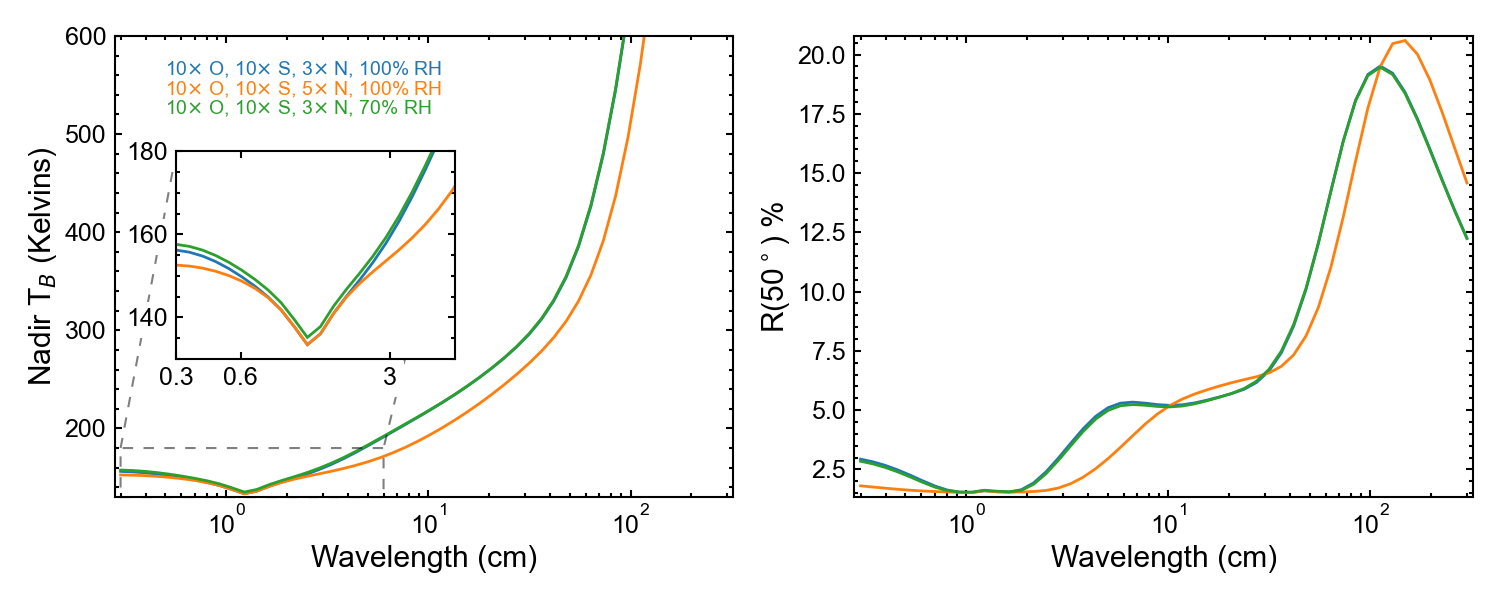

In [58]:
wave_cm = np.logspace(np.log10(0.3), np.log10(300), 50)  # One fn run takes 15s (30s for 100) 
freq_ghz = spc.c / (wave_cm * 1e-2) * 1e-9 

p_grid = np.logspace(2, 10, 10000)
saturn_gravity = 10.44  # m/s2 
planet_radius = 60268  # km 

# Reference case
saturn_ro = np.loadtxt('/Users/akins/Documents/Codes/ECCM_MRTM/data/ro_profiles/saturn_cassini_schinder2011.txt', skiprows=3, delimiter=',')
saturn_pressure = saturn_ro[:, 0] * 1e2  # Pa
saturn_temperature = saturn_ro[:, 1]

# Case 1 - Nominal - 10X O, 10X S, 3XN
gases1 = eccm.solar_to_deep_mole_fraction(10) 
gases2 = eccm.solar_to_deep_mole_fraction(3) 
deep_h2o = gases1['H2O']
deep_nh3 = gases2['NH3']
deep_h2s = gases1['H2S']
deep_ch4 = gases1['CH4']
deep_ph3 = 0.
h2o_rh = 1
nh3_rh = 1


pressure_grid, temperature_grid, altitude_grid, \
x_h2o, x_nh3, x_h2s, x_ch4, x_ph3, x_h2, x_he, \
a_h2osolid, a_h2oliquid, a_h2osolution, \
a_nh3solid, a_nh3liquid, \
a_h2ssolid, a_h2sliquid, \
a_nh4sh, c_nh3h2o, \
a_ch4solid, a_ch4liquid, a_ph3solid  = eccm.eccm(p_grid, saturn_pressure, saturn_temperature, saturn_gravity,
                                                 deep_h2o, deep_nh3, deep_h2s, deep_ch4, deep_ph3, 0.88, 0.12,
                                                 nh3_rh = nh3_rh, h2o_rh = h2o_rh,
                                                 latent_heat_update=True, force_reference_above_pressure=1.*spc.bar)

minloc = np.argmin(abs(pressure_grid / spc.bar - 1e-3))
maxloc = np.argmin(abs(pressure_grid / spc.bar - 1000e3))
slc = slice(maxloc, minloc, 3)
incang_deg = 0. 
full_tau, weight_up, weight_limb, Tup, Tlimb = mrtm.mrtm(freq_ghz, incang_deg, altitude_grid[slc], pressure_grid[slc], temperature_grid[slc], x_h2o[slc], x_nh3[slc], x_h2s[slc], x_ch4[slc], x_ph3[slc], x_h2[slc], x_he[slc], planet_radius)
ref_spec1 = Tup 
incang_deg = 50. 
full_tau, weight_up, weight_limb, Tup, Tlimb = mrtm.mrtm(freq_ghz, incang_deg, altitude_grid[slc], pressure_grid[slc], temperature_grid[slc], x_h2o[slc], x_nh3[slc], x_h2s[slc], x_ch4[slc], x_ph3[slc], x_h2[slc], x_he[slc], planet_radius)
ldspec = Tup 
R50_1 = (ref_spec1 - ldspec) / ref_spec1 * 1e2 

# Case 2 - Mid - 10X O, 10X S, 5XN
gases1 = eccm.solar_to_deep_mole_fraction(10) 
gases2 = eccm.solar_to_deep_mole_fraction(5) 

deep_h2o = gases1['H2O']
deep_nh3 = gases2['NH3']
deep_h2s = gases1['H2S']
deep_ch4 = gases1['CH4']
deep_ph3 = 0.
h2o_rh = 1
nh3_rh = 1

pressure_grid, temperature_grid, altitude_grid, \
x_h2o, x_nh3, x_h2s, x_ch4, x_ph3, x_h2, x_he, \
a_h2osolid, a_h2oliquid, a_h2osolution, \
a_nh3solid, a_nh3liquid, \
a_h2ssolid, a_h2sliquid, \
a_nh4sh, c_nh3h2o, \
a_ch4solid, a_ch4liquid, a_ph3solid  = eccm.eccm(p_grid, saturn_pressure, saturn_temperature, saturn_gravity,
                                                 deep_h2o, deep_nh3, deep_h2s, deep_ch4, deep_ph3, 0.88, 0.12,
                                                 nh3_rh = nh3_rh, h2o_rh = h2o_rh,
                                                 latent_heat_update=True, force_reference_above_pressure=1.*spc.bar)

minloc = np.argmin(abs(pressure_grid / spc.bar - 1e-3))
maxloc = np.argmin(abs(pressure_grid / spc.bar - 1000e3))
slc = slice(maxloc, minloc, 3)
incang_deg = 0. 
full_tau, weight_up, weight_limb, Tup, Tlimb = mrtm.mrtm(freq_ghz, incang_deg, altitude_grid[slc], pressure_grid[slc], temperature_grid[slc], x_h2o[slc], x_nh3[slc], x_h2s[slc], x_ch4[slc], x_ph3[slc], x_h2[slc], x_he[slc], planet_radius)
ref_spec2 = Tup 
incang_deg = 50. 
full_tau, weight_up, weight_limb, Tup, Tlimb = mrtm.mrtm(freq_ghz, incang_deg, altitude_grid[slc], pressure_grid[slc], temperature_grid[slc], x_h2o[slc], x_nh3[slc], x_h2s[slc], x_ch4[slc], x_ph3[slc], x_h2[slc], x_he[slc], planet_radius)
ldspec = Tup 
R50_2 = (ref_spec2 - ldspec) / ref_spec2 * 1e2 


# Case 3 - Off - 10X O, 10X S, 3X N, 50% RH
gases1 = eccm.solar_to_deep_mole_fraction(10) 
gases2 = eccm.solar_to_deep_mole_fraction(3) 

deep_h2o = gases1['H2O']
deep_nh3 = gases2['NH3']
deep_h2s = gases1['H2S']
deep_ch4 = gases1['CH4']
deep_ph3 = 0.
h2o_rh = 0.7
nh3_rh = 0.7

pressure_grid, temperature_grid, altitude_grid, \
x_h2o, x_nh3, x_h2s, x_ch4, x_ph3, x_h2, x_he, \
a_h2osolid, a_h2oliquid, a_h2osolution, \
a_nh3solid, a_nh3liquid, \
a_h2ssolid, a_h2sliquid, \
a_nh4sh, c_nh3h2o, \
a_ch4solid, a_ch4liquid, a_ph3solid  = eccm.eccm(p_grid, saturn_pressure, saturn_temperature, saturn_gravity,
                                                 deep_h2o, deep_nh3, deep_h2s, deep_ch4, deep_ph3, 0.88, 0.12,
                                                 nh3_rh = nh3_rh, h2o_rh = h2o_rh,
                                                 latent_heat_update=True, force_reference_above_pressure=1.*spc.bar)

minloc = np.argmin(abs(pressure_grid / spc.bar - 1e-3))
maxloc = np.argmin(abs(pressure_grid / spc.bar - 1000e3))
slc = slice(maxloc, minloc, 3)
incang_deg = 0. 
full_tau, weight_up, weight_limb, Tup, Tlimb = mrtm.mrtm(freq_ghz, incang_deg, altitude_grid[slc], pressure_grid[slc], temperature_grid[slc], x_h2o[slc], x_nh3[slc], x_h2s[slc], x_ch4[slc], x_ph3[slc], x_h2[slc], x_he[slc], planet_radius)
ref_spec3 = Tup 
incang_deg = 50. 
full_tau, weight_up, weight_limb, Tup, Tlimb = mrtm.mrtm(freq_ghz, incang_deg, altitude_grid[slc], pressure_grid[slc], temperature_grid[slc], x_h2o[slc], x_nh3[slc], x_h2s[slc], x_ch4[slc], x_ph3[slc], x_h2[slc], x_he[slc], planet_radius)
ldspec = Tup 
R50_3 = (ref_spec3 - ldspec) / ref_spec3 * 1e2 

fig = plt.figure(figsize=(15, 6))
ax1 = fig.add_subplot(1,2,1)
ax2 = fig.add_subplot(1,2,2)
axins = ax1.inset_axes([0.1, 0.3, 0.45, 0.45], xlim=(3e-1, 6), ylim=(130, 180))

ax1.plot(wave_cm, ref_spec1)
ax2.plot(wave_cm, R50_1)
axins.plot(wave_cm, ref_spec1)
ax1.plot(wave_cm, ref_spec2)
ax2.plot(wave_cm, R50_2)
axins.plot(wave_cm, ref_spec2)
ax1.plot(wave_cm, ref_spec3)
ax2.plot(wave_cm, R50_3)
axins.plot(wave_cm, ref_spec3)

ax1.text(5e-1, 560, r'10$\times$ O, 10$\times$ S, 3$\times$ N, 100% RH', color='tab:blue', fontsize=14)
ax1.text(5e-1, 540, r'10$\times$ O, 10$\times$ S, 5$\times$ N, 100% RH', color='tab:orange', fontsize=14)
ax1.text(5e-1, 520, r'10$\times$ O, 10$\times$ S, 3$\times$ N, 70% RH', color='tab:green', fontsize=14)
insind = ax1.indicate_inset_zoom(axins, edgecolor="black", ls=(0, (5, 5)))
insind.connectors[0].set_visible(False)
insind.connectors[1].set_visible(True)
insind.connectors[2].set_visible(False)
insind.connectors[3].set_visible(True)
ax1.set_xlabel('Wavelength (cm)')
ax2.set_xlabel('Wavelength (cm)')
ax1.set_ylabel('Nadir T$_B$ (Kelvins)')
ax2.set_ylabel('R(50$^\circ$) %')
ax1.set_xscale('log')
ax2.set_xscale('log')
axins.set_xscale('log')
axins.set_xticks([3e-1, 6e-1, 3])
axins.set_xticklabels([3e-1, 6e-1, 3], backgroundcolor="w")
axins.yaxis.set_ticklabels(axins.yaxis.get_ticklabels(), backgroundcolor='w')
axins.set()
axins.xaxis.minorticks_off()
ax1.set_ylim(130, 600)
fig.tight_layout()
fig.savefig('saturn_basic_spectrum.png') 

### Spectrum sensitivity for Saturn 

Deep ATM:   0%|          | 0/3 [00:00<?, ?it/s]

RH:   0%|          | 0/2 [00:00<?, ?it/s]

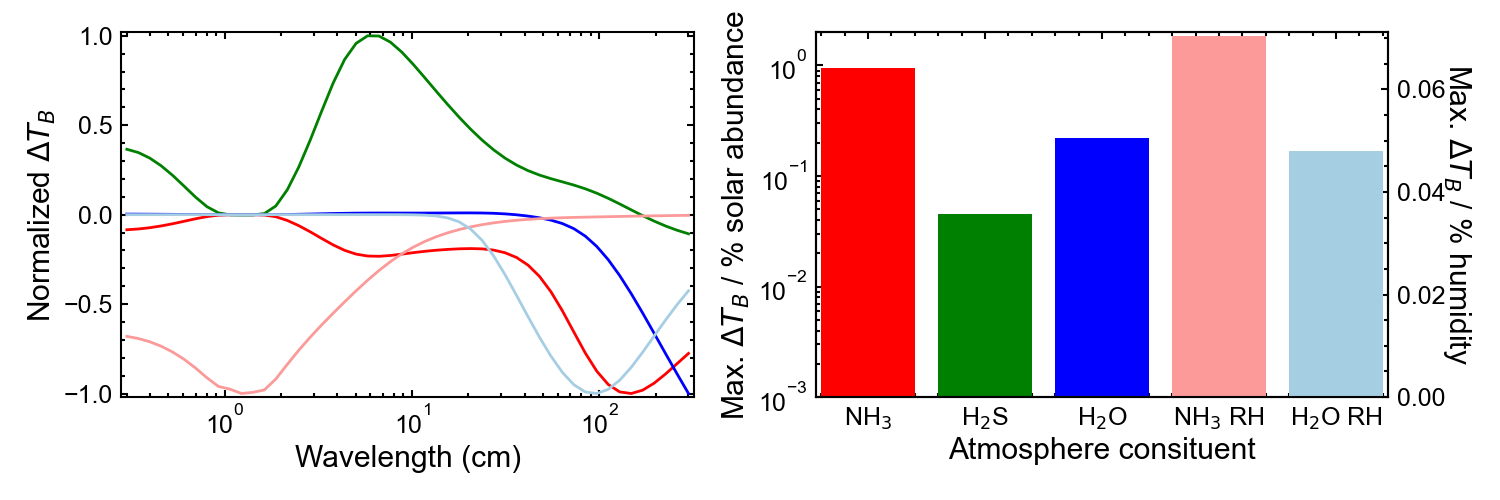

In [4]:
wave_cm = np.logspace(np.log10(0.3), np.log10(300), 50)  # One fn run takes 15s (30s for 100) 
freq_ghz = spc.c / (wave_cm * 1e-2) * 1e-9 
incang_deg = 0. 

step_gases = ['NH3', 'H2S', 'H2O']
rh_gases = ['NH3', 'H2O']
sg_psa = [1.48e-4, 2.89e-5, 1.07e-3]  # Solar ratios
label_dict = {'NH3': r'NH$_3$', 'H2S': r'H$_2$S','H2O': r'H$_2$O'}
paired_cmap = plt.get_cmap('Paired')
colors = ['r', 'g', 'b', paired_cmap(4), paired_cmap(0)]

p_grid = np.logspace(2, 10, 10000)
saturn_gravity = 10.44  # m/s2 
planet_radius = 60268  # km 

# Reference case
saturn_ro = np.loadtxt('/Users/akins/Documents/Codes/ECCM_MRTM/data/ro_profiles/saturn_cassini_schinder2011.txt', skiprows=3, delimiter=',')
saturn_pressure = saturn_ro[:, 0] * 1e2  # Pa
saturn_temperature = saturn_ro[:, 1]
gases1 = eccm.solar_to_deep_mole_fraction(10) 
gases2 = eccm.solar_to_deep_mole_fraction(3) 


deep_h2o = gases1['H2O']
deep_nh3 = gases2['NH3']
deep_h2s = gases1['H2S']
deep_ch4 = gases1['CH4']
deep_ph3 = 0.

pressure_grid, temperature_grid, altitude_grid, \
x_h2o, x_nh3, x_h2s, x_ch4, x_ph3, x_h2, x_he, \
a_h2osolid, a_h2oliquid, a_h2osolution, \
a_nh3solid, a_nh3liquid, \
a_h2ssolid, a_h2sliquid, \
a_nh4sh, c_nh3h2o, \
a_ch4solid, a_ch4liquid, a_ph3solid  = eccm.eccm(p_grid, saturn_pressure, saturn_temperature, saturn_gravity,
                                                 deep_h2o, deep_nh3, deep_h2s, deep_ch4, deep_ph3, 0.88, 0.12,
                                                 nh3_rh = 0.7, h2o_rh = 0.7,
                                                 latent_heat_update=True, force_reference_above_pressure=1.*spc.bar)

minloc = np.argmin(abs(pressure_grid / spc.bar - 1e-3))
maxloc = np.argmin(abs(pressure_grid / spc.bar - 1000e3))
slc = slice(maxloc, minloc, 3)
full_tau, weight_up, weight_limb, Tup, Tlimb = mrtm.mrtm(freq_ghz, incang_deg, altitude_grid[slc], pressure_grid[slc], temperature_grid[slc], x_h2o[slc], x_nh3[slc], x_h2s[slc], x_ch4[slc], x_ph3[slc], x_h2[slc], x_he[slc], planet_radius)
ref_spec = Tup 
this_jac_list = [] 

fig, axs = plt.subplots(1, 2, figsize=(15, 5))
tax = axs[1].twinx()

for j, sg in enumerate(tqdm(step_gases, desc='Deep ATM')):
    if sg == 'NH3': 
        use_deep_nh3 = deep_nh3 + 1e-2 * sg_psa[0]
        use_deep_h2s = deep_h2s 
        use_deep_h2o = deep_h2o
    elif sg == 'H2S': 
        use_deep_nh3 = deep_nh3 
        use_deep_h2s = deep_h2s + 1e-2 * sg_psa[1]
        use_deep_h2o = deep_h2o
    else: 
        use_deep_nh3 = deep_nh3 
        use_deep_h2s = deep_h2s 
        use_deep_h2o = deep_h2o + 1e-2 * sg_psa[2]

    pressure_grid, temperature_grid, altitude_grid, \
    x_h2o, x_nh3, x_h2s, x_ch4, x_ph3, x_h2, x_he, \
    a_h2osolid, a_h2oliquid, a_h2osolution, \
    a_nh3solid, a_nh3liquid, \
    a_h2ssolid, a_h2sliquid, \
    a_nh4sh, c_nh3h2o, \
    a_ch4solid, a_ch4liquid, a_ph3solid  = eccm.eccm(p_grid, saturn_pressure, saturn_temperature, saturn_gravity,
                                                     use_deep_h2o, use_deep_nh3, use_deep_h2s, deep_ch4, deep_ph3, 0.88, 0.12,
                                                     nh3_rh=0.7, h2o_rh=0.7, latent_heat_update=True, force_reference_above_pressure=1.*spc.bar)

    full_tau, weight_up, weight_limb, Tup, Tlimb = mrtm.mrtm(freq_ghz, incang_deg, altitude_grid[slc], pressure_grid[slc], temperature_grid[slc], x_h2o[slc], x_nh3[slc], x_h2s[slc], x_ch4[slc], x_ph3[slc], x_h2[slc], x_he[slc], planet_radius)
    this_jac = (Tup - ref_spec) / 1e-2 
    this_jac_list.append(this_jac.copy()) 

for j, rhg in enumerate(tqdm(rh_gases, desc='RH')):
    if rhg == 'NH3': 
        use_nh3_rh = 0.7 + 1e-2 
        use_h2o_rh = 0.7 
    else: 
        use_nh3_rh = 0.7 
        use_h2o_rh = 0.7 + 1e-2 
    pressure_grid, temperature_grid, altitude_grid, \
    x_h2o, x_nh3, x_h2s, x_ch4, x_ph3, x_h2, x_he, \
    a_h2osolid, a_h2oliquid, a_h2osolution, \
    a_nh3solid, a_nh3liquid, \
    a_h2ssolid, a_h2sliquid, \
    a_nh4sh, c_nh3h2o, \
    a_ch4solid, a_ch4liquid, a_ph3solid  = eccm.eccm(p_grid, saturn_pressure, saturn_temperature, saturn_gravity,
                                                     deep_h2o, deep_nh3, deep_h2s, deep_ch4, deep_ph3, 0.88, 0.12,
                                                     nh3_rh=use_nh3_rh, h2o_rh=use_h2o_rh, latent_heat_update=True, force_reference_above_pressure=1.*spc.bar)
    full_tau, weight_up, weight_limb, Tup, Tlimb = mrtm.mrtm(freq_ghz, incang_deg, altitude_grid[slc], pressure_grid[slc], temperature_grid[slc], x_h2o[slc], x_nh3[slc], x_h2s[slc], x_ch4[slc], x_ph3[slc], x_h2[slc], x_he[slc], planet_radius)
    this_jac = (Tup - ref_spec) / 1e-2 
    this_jac_list.append(this_jac.copy()) 

for j, tj in enumerate(this_jac_list): 
    if j < 3: 
        use_label = label_dict[step_gases[j]]
        axs[1].bar(use_label, np.max(abs(tj)) * 1e-2 , color=colors[j], label=use_label)
    else:
        use_label = label_dict[rh_gases[j - 3]] + ' RH' 
        tax.bar(use_label, np.max(abs(tj)) * 1e-2 , color=colors[j], label=use_label)
    axs[0].semilogx(wave_cm, tj / np.max(abs(tj)), color=colors[j], label=use_label)
        
axs[0].set_xlabel('Wavelength (cm)')
axs[0].set_ylabel(r'Normalized $\Delta T_B$')
axs[1].set_xlabel('Atmosphere consituent')
axs[1].set_ylabel(r'Max. $\Delta T_B$ / % solar abundance')
tax.set_ylabel(r'Max. $\Delta T_B$ / % humidity', rotation=-90, labelpad=20)
# axs[0].legend()
axs[1].set_yscale('log')
axs[1].set_ylim(1e-3, 2)

fig.tight_layout()    
fig.savefig('saturn_dTB.png')

### Basic spectrum for Uranus

<>:143: SyntaxWarning: invalid escape sequence '\c'
<>:143: SyntaxWarning: invalid escape sequence '\c'
/var/folders/zg/yqp2bsw569ngkkjdlpj0b5cw0000gq/T/ipykernel_52572/17975961.py:143: SyntaxWarning: invalid escape sequence '\c'
  ax2.set_ylabel('R(50$^\circ$) %')


Temperature profile matching iteration is either diverging or oscillating, 
                         printing current offset and moving ahead anyway
0.052565251685095404


/var/folders/zg/yqp2bsw569ngkkjdlpj0b5cw0000gq/T/ipykernel_52572/17975961.py:149: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axins.yaxis.set_ticklabels(axins.yaxis.get_ticklabels(), backgroundcolor='w')


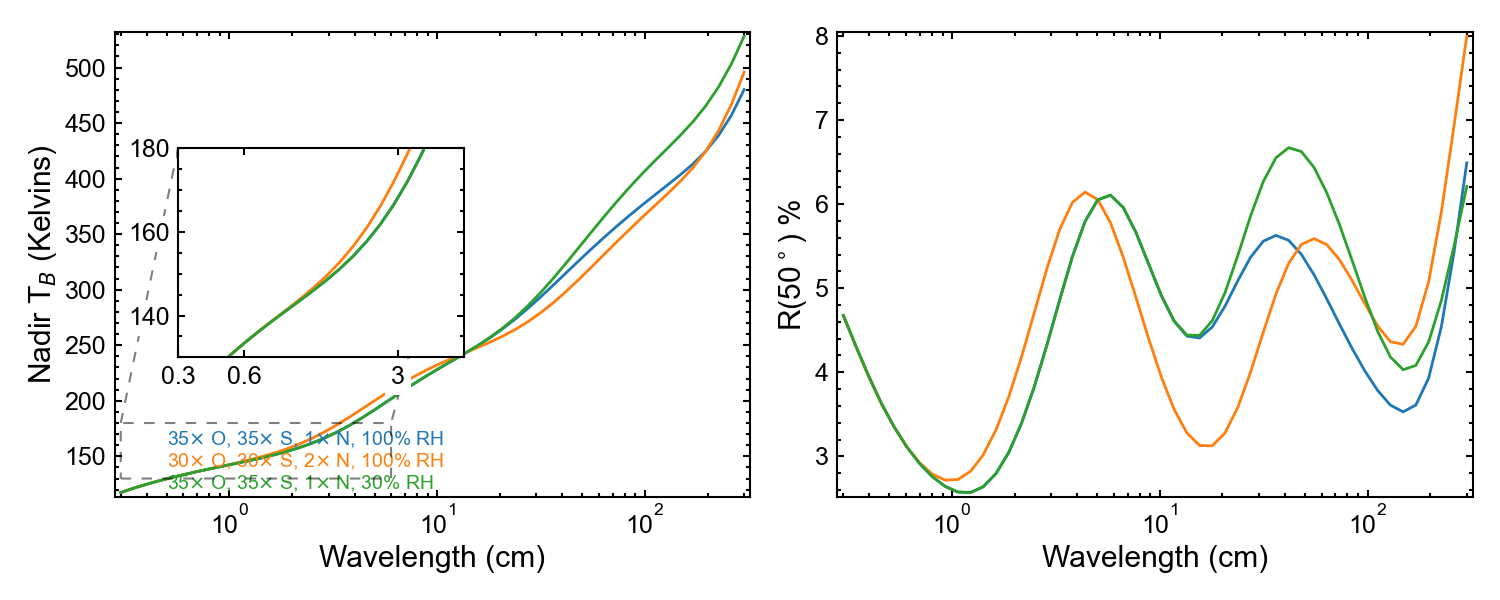

In [ ]:
wave_cm = np.logspace(np.log10(0.3), np.log10(300), 50)  # One fn run takes 15s (30s for 100) 
freq_ghz = spc.c / (wave_cm * 1e-2) * 1e-9 

p_grid = np.logspace(2, 10, 10000)
uranus_gravity = 8.87  # m/s2 
planet_radius = 25559  # km 

# Reference case
uranus_ro = np.loadtxt('/Users/akins/Documents/Codes/ECCM_MRTM/data/ro_profiles/uranus_voyager2_lindal1987.txt', skiprows=3, delimiter=',')
uranus_pressure = uranus_ro[:, 0] * 1e2  # Pa
uranus_temperature = uranus_ro[:, 1]
gases1 = eccm.solar_to_deep_mole_fraction(35) 
gases2 = eccm.solar_to_deep_mole_fraction(50) 
gases3 = eccm.solar_to_deep_mole_fraction(1) 

deep_h2o = gases1['H2O']
deep_nh3 = gases3['NH3']
deep_h2s = gases1['H2S']
deep_ch4 = gases2['CH4']
deep_ph3 = 0.
h2s_rh=1.
h2o_rh=1.

pressure_grid, temperature_grid, altitude_grid, \
x_h2o, x_nh3, x_h2s, x_ch4, x_ph3, x_h2, x_he, \
a_h2osolid, a_h2oliquid, a_h2osolution, \
a_nh3solid, a_nh3liquid, \
a_h2ssolid, a_h2sliquid, \
a_nh4sh, c_nh3h2o, \
a_ch4solid, a_ch4liquid, a_ph3solid  = eccm.eccm(p_grid, uranus_pressure, uranus_temperature, uranus_gravity,
                                                 deep_h2o, deep_nh3, deep_h2s, deep_ch4, deep_ph3, 0.85, 0.15,
                                                 h2s_rh = h2s_rh, h2o_rh = h2o_rh,
                                                 latent_heat_update=True, force_reference_above_pressure=1.*spc.bar)

minloc = np.argmin(abs(pressure_grid / spc.bar - 1e-3))
maxloc = np.argmin(abs(pressure_grid / spc.bar - 1000e3))
slc = slice(maxloc, minloc, 3)
incang_deg = 0. 
full_tau, weight_up, weight_limb, Tup, Tlimb = mrtm.mrtm(freq_ghz, incang_deg, altitude_grid[slc], pressure_grid[slc], temperature_grid[slc], x_h2o[slc], x_nh3[slc], x_h2s[slc], x_ch4[slc], x_ph3[slc], x_h2[slc], x_he[slc], planet_radius)
ref_spec1 = Tup 
incang_deg = 50. 
full_tau, weight_up, weight_limb, Tup, Tlimb = mrtm.mrtm(freq_ghz, incang_deg, altitude_grid[slc], pressure_grid[slc], temperature_grid[slc], x_h2o[slc], x_nh3[slc], x_h2s[slc], x_ch4[slc], x_ph3[slc], x_h2[slc], x_he[slc], planet_radius)
ldspec = Tup 
R50_1 = (ref_spec1 - ldspec) / ref_spec1 * 1e2 

# Case 2 - Mid 
gases1 = eccm.solar_to_deep_mole_fraction(30) 
gases2 = eccm.solar_to_deep_mole_fraction(50) 
gases3 = eccm.solar_to_deep_mole_fraction(2) 

deep_h2o = gases1['H2O']
deep_nh3 = gases3['NH3']
deep_h2s = gases1['H2S']
deep_ch4 = gases2['CH4']
deep_ph3 = 0.
h2s_rh=1.
h2o_rh=1.

pressure_grid, temperature_grid, altitude_grid, \
x_h2o, x_nh3, x_h2s, x_ch4, x_ph3, x_h2, x_he, \
a_h2osolid, a_h2oliquid, a_h2osolution, \
a_nh3solid, a_nh3liquid, \
a_h2ssolid, a_h2sliquid, \
a_nh4sh, c_nh3h2o, \
a_ch4solid, a_ch4liquid, a_ph3solid  = eccm.eccm(p_grid, uranus_pressure, uranus_temperature, uranus_gravity,
                                                 deep_h2o, deep_nh3, deep_h2s, deep_ch4, deep_ph3, 0.85, 0.15,
                                                 nh3_rh = nh3_rh, h2o_rh = h2o_rh,
                                                 latent_heat_update=True, force_reference_above_pressure=1.*spc.bar)

minloc = np.argmin(abs(pressure_grid / spc.bar - 1e-3))
maxloc = np.argmin(abs(pressure_grid / spc.bar - 1000e3))
slc = slice(maxloc, minloc, 3)
incang_deg = 0. 
full_tau, weight_up, weight_limb, Tup, Tlimb = mrtm.mrtm(freq_ghz, incang_deg, altitude_grid[slc], pressure_grid[slc], temperature_grid[slc], x_h2o[slc], x_nh3[slc], x_h2s[slc], x_ch4[slc], x_ph3[slc], x_h2[slc], x_he[slc], planet_radius)
ref_spec2 = Tup 
incang_deg = 50. 
full_tau, weight_up, weight_limb, Tup, Tlimb = mrtm.mrtm(freq_ghz, incang_deg, altitude_grid[slc], pressure_grid[slc], temperature_grid[slc], x_h2o[slc], x_nh3[slc], x_h2s[slc], x_ch4[slc], x_ph3[slc], x_h2[slc], x_he[slc], planet_radius)
ldspec = Tup 
R50_2 = (ref_spec2 - ldspec) / ref_spec2 * 1e2 


# Case 3 - Off - 10X O, 10X S, 3X N, 50% RH
gases1 = eccm.solar_to_deep_mole_fraction(35) 
gases2 = eccm.solar_to_deep_mole_fraction(50) 
gases3 = eccm.solar_to_deep_mole_fraction(1) 

deep_h2o = gases1['H2O']
deep_nh3 = gases3['NH3']
deep_h2s = gases1['H2S']
deep_ch4 = gases2['CH4']
deep_ph3 = 0.
h2s_rh=0.3
h2o_rh=0.3

pressure_grid, temperature_grid, altitude_grid, \
x_h2o, x_nh3, x_h2s, x_ch4, x_ph3, x_h2, x_he, \
a_h2osolid, a_h2oliquid, a_h2osolution, \
a_nh3solid, a_nh3liquid, \
a_h2ssolid, a_h2sliquid, \
a_nh4sh, c_nh3h2o, \
a_ch4solid, a_ch4liquid, a_ph3solid  = eccm.eccm(p_grid, uranus_pressure, uranus_temperature, uranus_gravity,
                                                 deep_h2o, deep_nh3, deep_h2s, deep_ch4, deep_ph3, 0.85, 0.15,
                                                 nh3_rh = nh3_rh, h2o_rh = h2o_rh,
                                                 latent_heat_update=True, force_reference_above_pressure=1.*spc.bar)

minloc = np.argmin(abs(pressure_grid / spc.bar - 1e-3))
maxloc = np.argmin(abs(pressure_grid / spc.bar - 1000e3))
slc = slice(maxloc, minloc, 3)
incang_deg = 0. 
full_tau, weight_up, weight_limb, Tup, Tlimb = mrtm.mrtm(freq_ghz, incang_deg, altitude_grid[slc], pressure_grid[slc], temperature_grid[slc], x_h2o[slc], x_nh3[slc], x_h2s[slc], x_ch4[slc], x_ph3[slc], x_h2[slc], x_he[slc], planet_radius)
ref_spec3 = Tup 
incang_deg = 50. 
full_tau, weight_up, weight_limb, Tup, Tlimb = mrtm.mrtm(freq_ghz, incang_deg, altitude_grid[slc], pressure_grid[slc], temperature_grid[slc], x_h2o[slc], x_nh3[slc], x_h2s[slc], x_ch4[slc], x_ph3[slc], x_h2[slc], x_he[slc], planet_radius)
ldspec = Tup 
R50_3 = (ref_spec3 - ldspec) / ref_spec3 * 1e2 

fig = plt.figure(figsize=(15, 6))
ax1 = fig.add_subplot(1,2,1)
ax2 = fig.add_subplot(1,2,2)

ax1.plot(wave_cm, ref_spec1)
ax2.plot(wave_cm, R50_1)
ax1.plot(wave_cm, ref_spec2)
ax2.plot(wave_cm, R50_2)
ax1.plot(wave_cm, ref_spec3)
ax2.plot(wave_cm, R50_3)

ax1.text(5e-1, 360, r'35$\times$ O, 35$\times$ S, 1$\times$ N, 100% RH', color='tab:blue', fontsize=14)
ax1.text(5e-1, 340, r'30$\times$ O, 30$\times$ S, 2$\times$ N, 100% RH', color='tab:orange', fontsize=14)
ax1.text(5e-1, 320, r'35$\times$ O, 35$\times$ S, 1$\times$ N, 30% RH', color='tab:green', fontsize=14)
ax1.set_xlabel('Wavelength (cm)')
ax2.set_xlabel('Wavelength (cm)')
ax1.set_ylabel('Nadir T$_B$ (Kelvins)')
ax2.set_ylabel('R(50$^\circ$) %')
ax1.set_xscale('log')
ax2.set_xscale('log')
ax2.set_ylim(1, 10)
fig.tight_layout()
fig.savefig('uranus_basic_spectrum.png') 

### Spectrum sensitivity for Uranus 

Deep ATM:   0%|          | 0/3 [00:00<?, ?it/s]

RH:   0%|          | 0/2 [00:00<?, ?it/s]

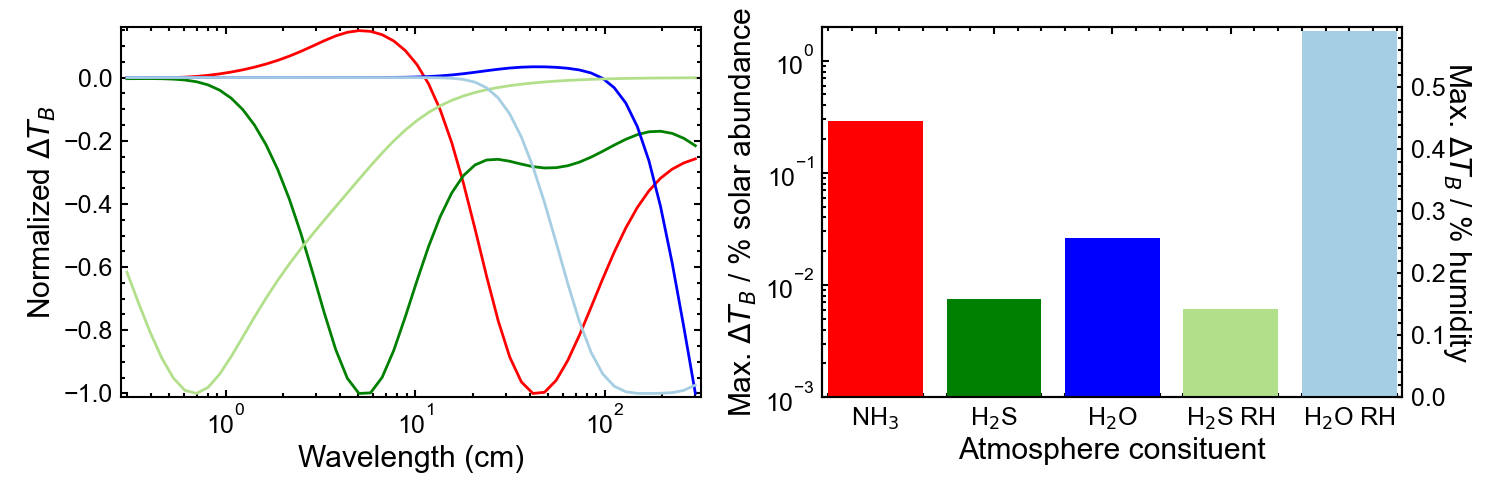

In [5]:
wave_cm = np.logspace(np.log10(0.3), np.log10(300), 50)  # One fn run takes 15s (30s for 100) 
freq_ghz = spc.c / (wave_cm * 1e-2) * 1e-9 
incang_deg = 0. 

step_gases = ['NH3', 'H2S', 'H2O']
rh_gases = ['H2S', 'H2O']
sg_psa = [1.48e-4, 2.89e-5, 1.07e-3]  # Solar ratios
label_dict = {'NH3': r'NH$_3$', 'H2S': r'H$_2$S','H2O': r'H$_2$O'}
paired_cmap = plt.get_cmap('Paired')
colors = ['r', 'g', 'b', paired_cmap(2), paired_cmap(0)]

p_grid = np.logspace(2, 10, 10000)
uranus_gravity = 8.87  # m/s2 
planet_radius = 25559  # km 

# Reference case
uranus_ro = np.loadtxt('/Users/akins/Documents/Codes/ECCM_MRTM/data/ro_profiles/uranus_voyager2_lindal1987.txt', skiprows=3, delimiter=',')
uranus_pressure = uranus_ro[:, 0] * 1e2  # Pa
uranus_temperature = uranus_ro[:, 1]
gases1 = eccm.solar_to_deep_mole_fraction(35) 
gases2 = eccm.solar_to_deep_mole_fraction(50) 
gases3 = eccm.solar_to_deep_mole_fraction(1) 

deep_h2o = gases1['H2O']
deep_nh3 = gases3['NH3']
deep_h2s = gases1['H2S']
deep_ch4 = gases2['CH4']


pressure_grid, temperature_grid, altitude_grid, \
x_h2o, x_nh3, x_h2s, x_ch4, x_ph3, x_h2, x_he, \
a_h2osolid, a_h2oliquid, a_h2osolution, \
a_nh3solid, a_nh3liquid, \
a_h2ssolid, a_h2sliquid, \
a_nh4sh, c_nh3h2o, \
a_ch4solid, a_ch4liquid, a_ph3solid  = eccm.eccm(p_grid, uranus_pressure, uranus_temperature, uranus_gravity,
                                                 gases1['H2O'], gases3['NH3'], gases1['H2S'], gases2['CH4'], 0., 0.85, 0.15,
                                                 h2s_rh=0.35, h2o_rh=0.35, latent_heat_update=True, force_reference_above_pressure=1.*spc.bar)

minloc = np.argmin(abs(pressure_grid / spc.bar - 1e-3))
maxloc = np.argmin(abs(pressure_grid / spc.bar - 1000e3))
slc = slice(maxloc, minloc, 3)
full_tau, weight_up, weight_limb, Tup, Tlimb = mrtm.mrtm(freq_ghz, incang_deg, altitude_grid[slc], pressure_grid[slc], temperature_grid[slc], x_h2o[slc], x_nh3[slc], x_h2s[slc], x_ch4[slc], x_ph3[slc], x_h2[slc], x_he[slc], planet_radius)
ref_spec = Tup 
this_jac_list = [] 

fig, axs = plt.subplots(1, 2, figsize=(15, 5))
tax = axs[1].twinx()

for j, sg in enumerate(tqdm(step_gases, desc='Deep ATM')):
    if sg == 'NH3': 
        use_deep_nh3 = deep_nh3 + 1e-2 * sg_psa[0]
        use_deep_h2s = deep_h2s 
        use_deep_h2o = deep_h2o
    elif sg == 'H2S': 
        use_deep_nh3 = deep_nh3 
        use_deep_h2s = deep_h2s + 1e-2 * sg_psa[1]
        use_deep_h2o = deep_h2o
    else: 
        use_deep_nh3 = deep_nh3 
        use_deep_h2s = deep_h2s 
        use_deep_h2o = deep_h2o + 1e-2 * sg_psa[2]

    pressure_grid, temperature_grid, altitude_grid, \
    x_h2o, x_nh3, x_h2s, x_ch4, x_ph3, x_h2, x_he, \
    a_h2osolid, a_h2oliquid, a_h2osolution, \
    a_nh3solid, a_nh3liquid, \
    a_h2ssolid, a_h2sliquid, \
    a_nh4sh, c_nh3h2o, \
    a_ch4solid, a_ch4liquid, a_ph3solid  = eccm.eccm(p_grid, uranus_pressure, uranus_temperature, uranus_gravity,
                                                     use_deep_h2o, use_deep_nh3, use_deep_h2s, deep_ch4, 0., 0.85, 0.15,
                                                     h2s_rh=0.35, h2o_rh=0.35, latent_heat_update=True, force_reference_above_pressure=1.*spc.bar)

    full_tau, weight_up, weight_limb, Tup, Tlimb = mrtm.mrtm(freq_ghz, incang_deg, altitude_grid[slc], pressure_grid[slc], temperature_grid[slc], x_h2o[slc], x_nh3[slc], x_h2s[slc], x_ch4[slc], x_ph3[slc], x_h2[slc], x_he[slc], planet_radius)
    this_jac = (Tup - ref_spec) / 1e-2 
    this_jac_list.append(this_jac.copy()) 

for j, rhg in enumerate(tqdm(rh_gases, desc='RH')):
    if rhg == 'H2S': 
        use_h2s_rh = 0.35 + 1e-2 
        use_h2o_rh = 0.35 
    else: 
        use_h2s_rh = 0.35 
        use_h2o_rh = 0.35 + 1e-2 
    pressure_grid, temperature_grid, altitude_grid, \
    x_h2o, x_nh3, x_h2s, x_ch4, x_ph3, x_h2, x_he, \
    a_h2osolid, a_h2oliquid, a_h2osolution, \
    a_nh3solid, a_nh3liquid, \
    a_h2ssolid, a_h2sliquid, \
    a_nh4sh, c_nh3h2o, \
    a_ch4solid, a_ch4liquid, a_ph3solid  = eccm.eccm(p_grid, uranus_pressure, uranus_temperature, uranus_gravity,
                                                     deep_h2o, deep_nh3, deep_h2s, deep_ch4, 0., 0.85, 0.15,
                                                     h2s_rh=use_h2s_rh, h2o_rh=use_h2o_rh, latent_heat_update=True, force_reference_above_pressure=1.*spc.bar)
    full_tau, weight_up, weight_limb, Tup, Tlimb = mrtm.mrtm(freq_ghz, incang_deg, altitude_grid[slc], pressure_grid[slc], temperature_grid[slc], x_h2o[slc], x_nh3[slc], x_h2s[slc], x_ch4[slc], x_ph3[slc], x_h2[slc], x_he[slc], planet_radius)
    this_jac = (Tup - ref_spec) / 1e-2 
    this_jac_list.append(this_jac.copy()) 

for j, tj in enumerate(this_jac_list): 
    if j < 3: 
        use_label = label_dict[step_gases[j]]
        axs[1].bar(use_label, np.max(abs(tj)) * 1e-2 , color=colors[j], label=use_label)
    else:
        use_label = label_dict[rh_gases[j - 3]] + ' RH' 
        tax.bar(use_label, np.max(abs(tj)) * 1e-2 , color=colors[j], label=use_label)
    axs[0].semilogx(wave_cm, tj / np.max(abs(tj)), color=colors[j], label=use_label)
        
axs[0].set_xlabel('Wavelength (cm)')
axs[0].set_ylabel(r'Normalized $\Delta T_B$')
axs[1].set_xlabel('Atmosphere consituent')
axs[1].set_ylabel(r'Max. $\Delta T_B$ / % solar abundance')
tax.set_ylabel(r'Max. $\Delta T_B$ / % humidity', rotation=-90, labelpad=20)
# axs[0].legend()
axs[1].set_yscale('log')
axs[1].set_ylim(1e-3, 2)

fig.tight_layout()    
fig.savefig('uranus_dTB.png')
    


## Model perturbation tests - Saturn
### Deep water abundance  

<>:135: SyntaxWarning: invalid escape sequence '\c'
<>:135: SyntaxWarning: invalid escape sequence '\c'
/var/folders/zg/yqp2bsw569ngkkjdlpj0b5cw0000gq/T/ipykernel_52572/3073173881.py:135: SyntaxWarning: invalid escape sequence '\c'
  ax2.set_ylabel('R(50$^\circ$) %')


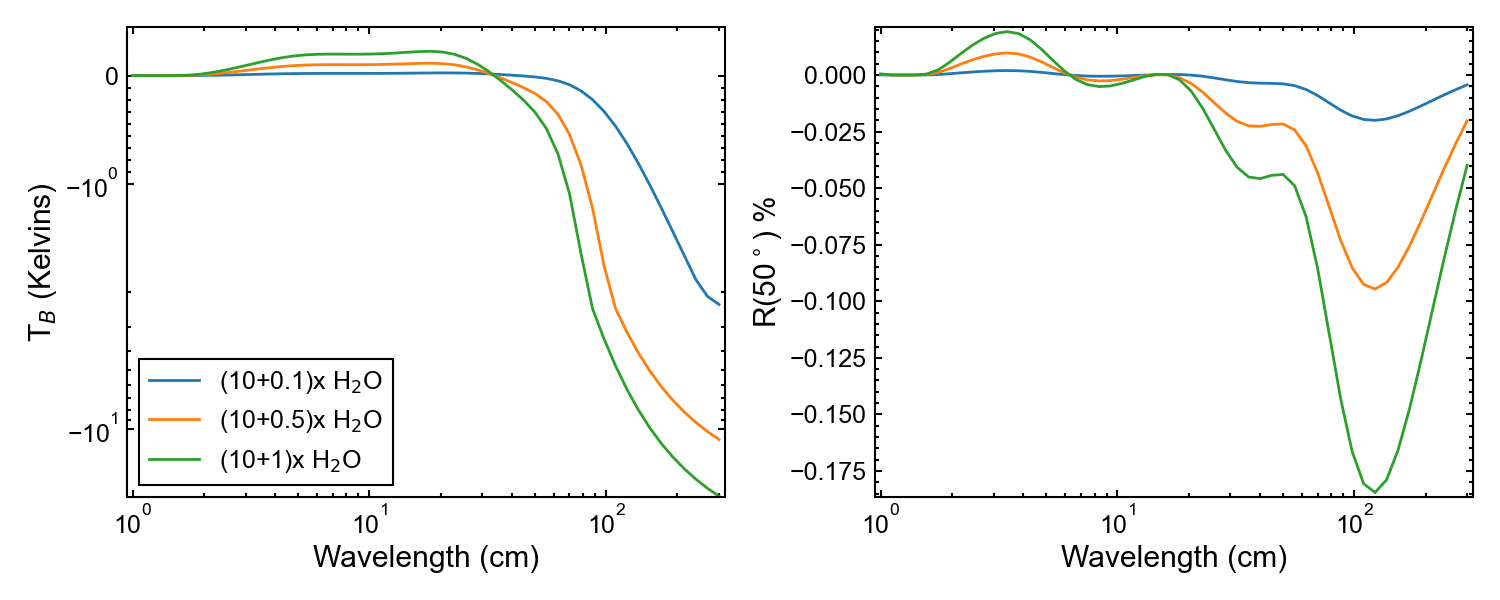

In [59]:
p_grid = np.logspace(2, 10, 10000)
saturn_gravity = 10.44  # m/s2 
planet_radius = 60268  # Saturn
freq_ghz = 3e-1 / np.logspace(np.log10(1e-2), np.log10(3), 52)
wave_cm = spc.c / (freq_ghz * 1e9) * 1e2 

fig = plt.figure(figsize=(15, 6))
ax1 = fig.add_subplot(1,2,1)
ax2 = fig.add_subplot(1,2,2)

# Load RO profile 
saturn_ro = np.loadtxt('/Users/akins/Documents/Codes/ECCM_MRTM/data/ro_profiles/saturn_cassini_schinder2011.txt', skiprows=3, delimiter=',')
saturn_pressure = saturn_ro[:, 0] * 1e2  # Pa
saturn_temperature = saturn_ro[:, 1]

# Baseline
gases1 = eccm.solar_to_deep_mole_fraction(10) 
gases2 = eccm.solar_to_deep_mole_fraction(3) 

pressure_grid, temperature_grid, altitude_grid, \
x_h2o, x_nh3, x_h2s, x_ch4, x_ph3, x_h2, x_he, \
a_h2osolid, a_h2oliquid, a_h2osolution, \
a_nh3solid, a_nh3liquid, \
a_h2ssolid, a_h2sliquid, \
a_nh4sh, c_nh3h2o, \
a_ch4solid, a_ch4liquid, a_ph3solid  = eccm.eccm(p_grid, saturn_pressure, saturn_temperature, saturn_gravity,
                                                 gases1['H2O'], gases2['NH3'], gases1['H2S'], gases1['CH4'], 0., 0.88, 0.12,
                                                 nh3_rh = 0.7, h2o_rh = 0.7,
                                                 latent_heat_update=False, force_reference_above_pressure=1.*spc.bar)

incang_deg = 0. 
# Don't need to use the full atmosphere grid
minloc = np.argmin(abs(pressure_grid / spc.bar - 1e-3))
maxloc = np.argmin(abs(pressure_grid / spc.bar - 10000e3))
slc = slice(maxloc, minloc, 3)
full_tau, weight_up, weight_limb, Tup, Tlimb = mrtm.mrtm(freq_ghz, incang_deg, altitude_grid[slc], pressure_grid[slc], temperature_grid[slc], x_h2o[slc], x_nh3[slc], x_h2s[slc], x_ch4[slc], x_ph3[slc], x_h2[slc], x_he[slc], planet_radius)
spec1 = Tup 
incang_deg = 50. 
full_tau, _, _, Tup, Tlimb = mrtm.mrtm(freq_ghz, incang_deg, altitude_grid[slc], pressure_grid[slc], temperature_grid[slc], x_h2o[slc], x_nh3[slc], x_h2s[slc], x_ch4[slc], x_ph3[slc], x_h2[slc], x_he[slc], planet_radius)
spec2 = Tup 
R50 = (spec1 - spec2) / spec1 * 1e2 
ref_spec = spec1
ref_50 = R50 

# Next 
gases1 = eccm.solar_to_deep_mole_fraction(10) 
gases2 = eccm.solar_to_deep_mole_fraction(3) 
gases3 = eccm.solar_to_deep_mole_fraction(10.1) 

pressure_grid, temperature_grid, altitude_grid, \
x_h2o, x_nh3, x_h2s, x_ch4, x_ph3, x_h2, x_he, \
a_h2osolid, a_h2oliquid, a_h2osolution, \
a_nh3solid, a_nh3liquid, \
a_h2ssolid, a_h2sliquid, \
a_nh4sh, c_nh3h2o, \
a_ch4solid, a_ch4liquid, a_ph3solid  = eccm.eccm(p_grid, saturn_pressure, saturn_temperature, saturn_gravity,
                                                 gases3['H2O'], gases2['NH3'], gases1['H2S'], gases1['CH4'], 0., 0.88, 0.12,
                                                 nh3_rh = 0.7, h2o_rh = 0.7,
                                                 latent_heat_update=False, force_reference_above_pressure=1.*spc.bar)

incang_deg = 0. 
full_tau, weight_up, weight_limb, Tup, Tlimb = mrtm.mrtm(freq_ghz, incang_deg, altitude_grid[slc], pressure_grid[slc], temperature_grid[slc], x_h2o[slc], x_nh3[slc], x_h2s[slc], x_ch4[slc], x_ph3[slc], x_h2[slc], x_he[slc], planet_radius)
spec1 = Tup 
incang_deg = 50. 
full_tau, _, _, Tup, Tlimb = mrtm.mrtm(freq_ghz, incang_deg, altitude_grid[slc], pressure_grid[slc], temperature_grid[slc], x_h2o[slc], x_nh3[slc], x_h2s[slc], x_ch4[slc], x_ph3[slc], x_h2[slc], x_he[slc], planet_radius)
spec2 = Tup 
R50 = (spec1 - spec2) / spec1 * 1e2 

ax1.plot(wave_cm, spec1-ref_spec, label='(10+0.1)x H$_2$O')
ax2.plot(wave_cm, R50-ref_50)
# ax1.plot(wave_cm, spec1, label='(10+0.1)x H$_2$O')
# ax2.plot(wave_cm, R50)

# Next 
gases1 = eccm.solar_to_deep_mole_fraction(10) 
gases2 = eccm.solar_to_deep_mole_fraction(3) 
gases3 = eccm.solar_to_deep_mole_fraction(10.5) 

pressure_grid, temperature_grid, altitude_grid, \
x_h2o, x_nh3, x_h2s, x_ch4, x_ph3, x_h2, x_he, \
a_h2osolid, a_h2oliquid, a_h2osolution, \
a_nh3solid, a_nh3liquid, \
a_h2ssolid, a_h2sliquid, \
a_nh4sh, c_nh3h2o, \
a_ch4solid, a_ch4liquid, a_ph3solid  = eccm.eccm(p_grid, saturn_pressure, saturn_temperature, saturn_gravity,
                                                 gases3['H2O'], gases2['NH3'], gases1['H2S'], gases1['CH4'], 0., 0.88, 0.12,
                                                 nh3_rh = 0.7, h2o_rh = 0.7,
                                                 latent_heat_update=False, force_reference_above_pressure=1.*spc.bar)

incang_deg = 0. 
full_tau, weight_up, weight_limb, Tup, Tlimb = mrtm.mrtm(freq_ghz, incang_deg, altitude_grid[slc], pressure_grid[slc], temperature_grid[slc], x_h2o[slc], x_nh3[slc], x_h2s[slc], x_ch4[slc], x_ph3[slc], x_h2[slc], x_he[slc], planet_radius)
spec1 = Tup 
incang_deg = 50. 
full_tau, _, _, Tup, Tlimb = mrtm.mrtm(freq_ghz, incang_deg, altitude_grid[slc], pressure_grid[slc], temperature_grid[slc], x_h2o[slc], x_nh3[slc], x_h2s[slc], x_ch4[slc], x_ph3[slc], x_h2[slc], x_he[slc], planet_radius)
spec2 = Tup 
R50 = (spec1 - spec2) / spec1 * 1e2 

ax1.plot(wave_cm, spec1-ref_spec, label='(10+0.5)x H$_2$O')
ax2.plot(wave_cm, R50-ref_50)
# ax1.plot(wave_cm, spec1, label='(10+0.5)x H$_2$O')
# ax2.plot(wave_cm, R50)

# Next 
gases1 = eccm.solar_to_deep_mole_fraction(10) 
gases2 = eccm.solar_to_deep_mole_fraction(3) 
gases3 = eccm.solar_to_deep_mole_fraction(11) 

pressure_grid, temperature_grid, altitude_grid, \
x_h2o, x_nh3, x_h2s, x_ch4, x_ph3, x_h2, x_he, \
a_h2osolid, a_h2oliquid, a_h2osolution, \
a_nh3solid, a_nh3liquid, \
a_h2ssolid, a_h2sliquid, \
a_nh4sh, c_nh3h2o, \
a_ch4solid, a_ch4liquid, a_ph3solid  = eccm.eccm(p_grid, saturn_pressure, saturn_temperature, saturn_gravity,
                                                 gases3['H2O'], gases2['NH3'], gases1['H2S'], gases1['CH4'], 0., 0.88, 0.12,
                                                 nh3_rh = 0.7, h2o_rh = 0.7,
                                                 latent_heat_update=False, force_reference_above_pressure=1.*spc.bar)

incang_deg = 0. 
full_tau, weight_up, weight_limb, Tup, Tlimb = mrtm.mrtm(freq_ghz, incang_deg, altitude_grid[slc], pressure_grid[slc], temperature_grid[slc], x_h2o[slc], x_nh3[slc], x_h2s[slc], x_ch4[slc], x_ph3[slc], x_h2[slc], x_he[slc], planet_radius)
spec1 = Tup 
incang_deg = 50. 
full_tau, _, _, Tup, Tlimb = mrtm.mrtm(freq_ghz, incang_deg, altitude_grid[slc], pressure_grid[slc], temperature_grid[slc], x_h2o[slc], x_nh3[slc], x_h2s[slc], x_ch4[slc], x_ph3[slc], x_h2[slc], x_he[slc], planet_radius)
spec2 = Tup 
R50 = (spec1 - spec2) / spec1 * 1e2 

ax1.plot(wave_cm, spec1-ref_spec, label='(10+1)x H$_2$O')
ax2.plot(wave_cm, R50-ref_50)
# ax1.plot(wave_cm, spec1, label='(10+1)x H$_2$O')
# ax2.plot(wave_cm, R50)

ax1.set_xlabel('Wavelength (cm)')
ax2.set_xlabel('Wavelength (cm)')
ax1.set_ylabel('T$_B$ (Kelvins)')
ax2.set_ylabel('R(50$^\circ$) %')
ax1.legend() 
ax1.set_xscale('log')
ax2.set_xscale('log')
ax1.set_yscale('symlog')
ax1.yaxis.set_minor_locator(MinorSymLogLocator(1e-1))
fig.tight_layout()
fig.savefig('saturn_water')

### Deep NH3 abundance  

<>:125: SyntaxWarning: invalid escape sequence '\c'
<>:125: SyntaxWarning: invalid escape sequence '\c'
/var/folders/zg/yqp2bsw569ngkkjdlpj0b5cw0000gq/T/ipykernel_79948/84269613.py:125: SyntaxWarning: invalid escape sequence '\c'
  ax2.set_ylabel('R(50$^\circ$) (%, difference from 3x)')


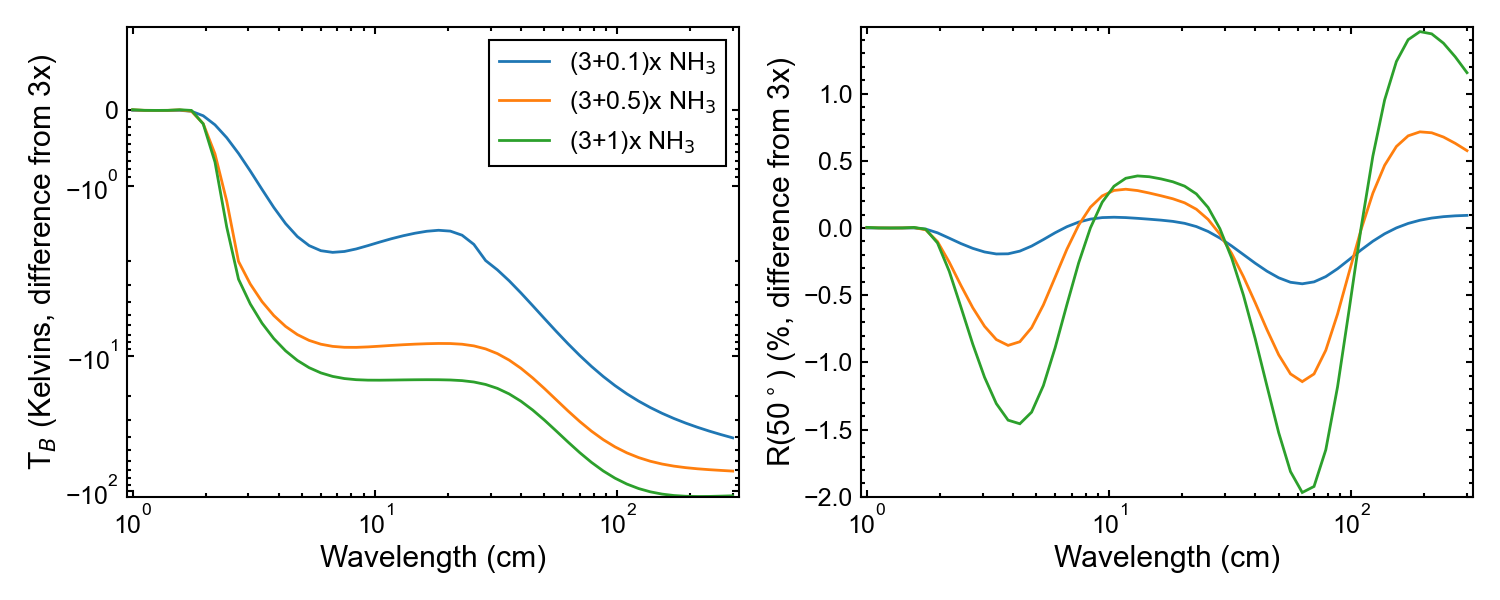

In [7]:
p_grid = np.logspace(2, 10, 10000)
saturn_gravity = 10.44  # m/s2 
planet_radius = 60268  # Saturn
freq_ghz = 3e-1 / np.logspace(np.log10(1e-2), np.log10(3), 52)
wave_cm = spc.c / (freq_ghz * 1e9) * 1e2 

fig = plt.figure(figsize=(15, 6))
ax1 = fig.add_subplot(1,2,1)
ax2 = fig.add_subplot(1,2,2)

# Load RO profile 
saturn_ro = np.loadtxt('/Users/akins/Documents/Codes/ECCM_MRTM/data/ro_profiles/saturn_cassini_schinder2011.txt', skiprows=3, delimiter=',')
saturn_pressure = saturn_ro[:, 0] * 1e2  # Pa
saturn_temperature = saturn_ro[:, 1]

# Baseline
gases1 = eccm.solar_to_deep_mole_fraction(10) 
gases2 = eccm.solar_to_deep_mole_fraction(3) 

pressure_grid, temperature_grid, altitude_grid, \
x_h2o, x_nh3, x_h2s, x_ch4, x_ph3, x_h2, x_he, \
a_h2osolid, a_h2oliquid, a_h2osolution, \
a_nh3solid, a_nh3liquid, \
a_h2ssolid, a_h2sliquid, \
a_nh4sh, c_nh3h2o, \
a_ch4solid, a_ch4liquid, a_ph3solid  = eccm.eccm(p_grid, saturn_pressure, saturn_temperature, saturn_gravity,
                                                 gases1['H2O'], gases2['NH3'], gases1['H2S'], gases1['CH4'], 0., 0.88, 0.12,
                                                 nh3_rh = 0.7, h2o_rh = 0.7,
                                                 latent_heat_update=True, force_reference_above_pressure=1.*spc.bar)

incang_deg = 0. 
# Don't need to use the full atmosphere grid
minloc = np.argmin(abs(pressure_grid / spc.bar - 1e-3))
maxloc = np.argmin(abs(pressure_grid / spc.bar - 10000e3))
slc = slice(maxloc, minloc, 3)
full_tau, weight_up, weight_limb, Tup, Tlimb = mrtm.mrtm(freq_ghz, incang_deg, altitude_grid[slc], pressure_grid[slc], temperature_grid[slc], x_h2o[slc], x_nh3[slc], x_h2s[slc], x_ch4[slc], x_ph3[slc], x_h2[slc], x_he[slc], planet_radius)
spec1 = Tup 
incang_deg = 50. 
full_tau, _, _, Tup, Tlimb = mrtm.mrtm(freq_ghz, incang_deg, altitude_grid[slc], pressure_grid[slc], temperature_grid[slc], x_h2o[slc], x_nh3[slc], x_h2s[slc], x_ch4[slc], x_ph3[slc], x_h2[slc], x_he[slc], planet_radius)
spec2 = Tup 
R50 = (spec1 - spec2) / spec1 * 1e2 
ref_spec = spec1
ref_50 = R50 

# Next 
gases1 = eccm.solar_to_deep_mole_fraction(10) 
gases2 = eccm.solar_to_deep_mole_fraction(3.1) 

pressure_grid, temperature_grid, altitude_grid, \
x_h2o, x_nh3, x_h2s, x_ch4, x_ph3, x_h2, x_he, \
a_h2osolid, a_h2oliquid, a_h2osolution, \
a_nh3solid, a_nh3liquid, \
a_h2ssolid, a_h2sliquid, \
a_nh4sh, c_nh3h2o, \
a_ch4solid, a_ch4liquid, a_ph3solid  = eccm.eccm(p_grid, saturn_pressure, saturn_temperature, saturn_gravity,
                                                 gases3['H2O'], gases2['NH3'], gases1['H2S'], gases1['CH4'], 0., 0.88, 0.12,
                                                 nh3_rh = 0.7, h2o_rh = 0.7,
                                                 latent_heat_update=True, force_reference_above_pressure=1.*spc.bar)

incang_deg = 0. 
full_tau, weight_up, weight_limb, Tup, Tlimb = mrtm.mrtm(freq_ghz, incang_deg, altitude_grid[slc], pressure_grid[slc], temperature_grid[slc], x_h2o[slc], x_nh3[slc], x_h2s[slc], x_ch4[slc], x_ph3[slc], x_h2[slc], x_he[slc], planet_radius)
spec1 = Tup 
incang_deg = 50. 
full_tau, _, _, Tup, Tlimb = mrtm.mrtm(freq_ghz, incang_deg, altitude_grid[slc], pressure_grid[slc], temperature_grid[slc], x_h2o[slc], x_nh3[slc], x_h2s[slc], x_ch4[slc], x_ph3[slc], x_h2[slc], x_he[slc], planet_radius)
spec2 = Tup 
R50 = (spec1 - spec2) / spec1 * 1e2 

ax1.plot(wave_cm, spec1-ref_spec, label='(3+0.1)x NH$_3$')
ax2.plot(wave_cm, R50-ref_50)

# Next 
gases1 = eccm.solar_to_deep_mole_fraction(10) 
gases2 = eccm.solar_to_deep_mole_fraction(3.5) 

pressure_grid, temperature_grid, altitude_grid, \
x_h2o, x_nh3, x_h2s, x_ch4, x_ph3, x_h2, x_he, \
a_h2osolid, a_h2oliquid, a_h2osolution, \
a_nh3solid, a_nh3liquid, \
a_h2ssolid, a_h2sliquid, \
a_nh4sh, c_nh3h2o, \
a_ch4solid, a_ch4liquid, a_ph3solid  = eccm.eccm(p_grid, saturn_pressure, saturn_temperature, saturn_gravity,
                                                 gases3['H2O'], gases2['NH3'], gases1['H2S'], gases1['CH4'], 0., 0.88, 0.12,
                                                 nh3_rh = 0.7, h2o_rh = 0.7,
                                                 latent_heat_update=True, force_reference_above_pressure=1.*spc.bar)

incang_deg = 0. 
full_tau, weight_up, weight_limb, Tup, Tlimb = mrtm.mrtm(freq_ghz, incang_deg, altitude_grid[slc], pressure_grid[slc], temperature_grid[slc], x_h2o[slc], x_nh3[slc], x_h2s[slc], x_ch4[slc], x_ph3[slc], x_h2[slc], x_he[slc], planet_radius)
spec1 = Tup 
incang_deg = 50. 
full_tau, _, _, Tup, Tlimb = mrtm.mrtm(freq_ghz, incang_deg, altitude_grid[slc], pressure_grid[slc], temperature_grid[slc], x_h2o[slc], x_nh3[slc], x_h2s[slc], x_ch4[slc], x_ph3[slc], x_h2[slc], x_he[slc], planet_radius)
spec2 = Tup 
R50 = (spec1 - spec2) / spec1 * 1e2 

ax1.plot(wave_cm, spec1-ref_spec, label='(3+0.5)x NH$_3$')
ax2.plot(wave_cm, R50-ref_50)
# Next 
gases1 = eccm.solar_to_deep_mole_fraction(10) 
gases2 = eccm.solar_to_deep_mole_fraction(4) 

pressure_grid, temperature_grid, altitude_grid, \
x_h2o, x_nh3, x_h2s, x_ch4, x_ph3, x_h2, x_he, \
a_h2osolid, a_h2oliquid, a_h2osolution, \
a_nh3solid, a_nh3liquid, \
a_h2ssolid, a_h2sliquid, \
a_nh4sh, c_nh3h2o, \
a_ch4solid, a_ch4liquid, a_ph3solid  = eccm.eccm(p_grid, saturn_pressure, saturn_temperature, saturn_gravity,
                                                 gases3['H2O'], gases2['NH3'], gases1['H2S'], gases1['CH4'], 0., 0.88, 0.12,
                                                 nh3_rh = 0.7, h2o_rh = 0.7,
                                                 latent_heat_update=True, force_reference_above_pressure=1.*spc.bar)

incang_deg = 0. 
full_tau, weight_up, weight_limb, Tup, Tlimb = mrtm.mrtm(freq_ghz, incang_deg, altitude_grid[slc], pressure_grid[slc], temperature_grid[slc], x_h2o[slc], x_nh3[slc], x_h2s[slc], x_ch4[slc], x_ph3[slc], x_h2[slc], x_he[slc], planet_radius)
spec1 = Tup 
incang_deg = 50. 
full_tau, _, _, Tup, Tlimb = mrtm.mrtm(freq_ghz, incang_deg, altitude_grid[slc], pressure_grid[slc], temperature_grid[slc], x_h2o[slc], x_nh3[slc], x_h2s[slc], x_ch4[slc], x_ph3[slc], x_h2[slc], x_he[slc], planet_radius)
spec2 = Tup 
R50 = (spec1 - spec2) / spec1 * 1e2 

ax1.plot(wave_cm, spec1-ref_spec, label='(3+1)x NH$_3$')
ax2.plot(wave_cm, R50-ref_50)

ax1.set_xlabel('Wavelength (cm)')
ax2.set_xlabel('Wavelength (cm)')
ax1.set_ylabel('T$_B$ (Kelvins, difference from 3x)')
ax2.set_ylabel('R(50$^\circ$) (%, difference from 3x)')
ax1.legend() 
ax1.set_xscale('log')
ax2.set_xscale('log')
ax1.set_yscale('symlog')
ax1.yaxis.set_minor_locator(MinorSymLogLocator(1e-1))

fig.tight_layout()
fig.savefig('saturn_ammonia')

## Uranus 
### Deep water abundance

<>:132: SyntaxWarning: invalid escape sequence '\c'
<>:132: SyntaxWarning: invalid escape sequence '\c'
/var/folders/zg/yqp2bsw569ngkkjdlpj0b5cw0000gq/T/ipykernel_79948/4028457267.py:132: SyntaxWarning: invalid escape sequence '\c'
  ax2.set_ylabel('R(50$^\circ$) (%, difference from 35x)')


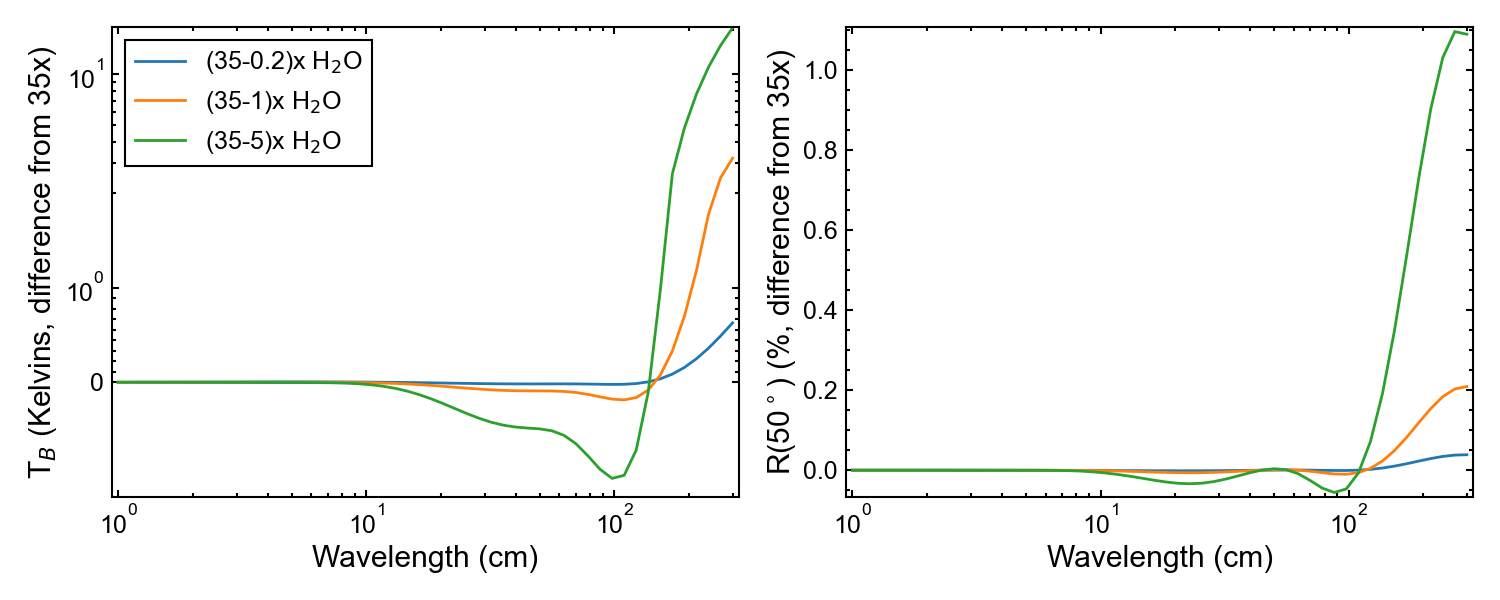

In [9]:
p_grid = np.logspace(2, 9, 10000)
uranus_gravity = 8.69  # m/s2 
planet_radius = 25559  
freq_ghz = 3e-1 / np.logspace(np.log10(1e-2), np.log10(3), 52)
wave_cm = spc.c / (freq_ghz * 1e9) * 1e2 

fig = plt.figure(figsize=(15, 6))
ax1 = fig.add_subplot(1,2,1)
ax2 = fig.add_subplot(1,2,2)

# Load RO profile 
uranus_ro = np.loadtxt('/Users/akins/Documents/Codes/ECCM_MRTM/data/ro_profiles/uranus_voyager2_lindal1987.txt', skiprows=3, delimiter=',')
uranus_pressure = uranus_ro[:, 0] * 1e2  # Pa
uranus_temperature = uranus_ro[:, 1]

# Baseline
gases1 = eccm.solar_to_deep_mole_fraction(50) 
gases2 = eccm.solar_to_deep_mole_fraction(35) 
gases3 = eccm.solar_to_deep_mole_fraction(1) 

pressure_grid, temperature_grid, altitude_grid, \
x_h2o, x_nh3, x_h2s, x_ch4, x_ph3, x_h2, x_he, \
a_h2osolid, a_h2oliquid, a_h2osolution, \
a_nh3solid, a_nh3liquid, \
a_h2ssolid, a_h2sliquid, \
a_nh4sh, c_nh3h2o, \
a_ch4solid, a_ch4liquid, a_ph3solid  = eccm.eccm(p_grid, uranus_pressure, uranus_temperature, uranus_gravity,
                                                 gases2['H2O'], gases3['NH3'], gases2['H2S'], gases1['CH4'], 0., 0.85, 0.15,
                                                 h2s_rh = 0.35, h2o_rh = 0.35,
                                                 latent_heat_update=True, force_reference_above_pressure=1.*spc.bar)

incang_deg = 0. 
# Don't need to use the full atmosphere grid
minloc = np.argmin(abs(pressure_grid / spc.bar - 1e-3))
maxloc = np.argmin(abs(pressure_grid / spc.bar - 1000e3))
slc = slice(maxloc, minloc, 3)
full_tau, weight_up, weight_limb, Tup, Tlimb = mrtm.mrtm(freq_ghz, incang_deg, altitude_grid[slc], pressure_grid[slc], temperature_grid[slc], x_h2o[slc], x_nh3[slc], x_h2s[slc], x_ch4[slc], x_ph3[slc], x_h2[slc], x_he[slc], planet_radius)
spec1 = Tup 
incang_deg = 50. 
full_tau, _, _, Tup, Tlimb = mrtm.mrtm(freq_ghz, incang_deg, altitude_grid[slc], pressure_grid[slc], temperature_grid[slc], x_h2o[slc], x_nh3[slc], x_h2s[slc], x_ch4[slc], x_ph3[slc], x_h2[slc], x_he[slc], planet_radius)
spec2 = Tup 
R50 = (spec1 - spec2) / spec1 * 1e2 
ref_spec = spec1
ref_50 = R50 

# Next 
gases1 = eccm.solar_to_deep_mole_fraction(50) 
gases2 = eccm.solar_to_deep_mole_fraction(35) 
gases3 = eccm.solar_to_deep_mole_fraction(1) 
gases4 = eccm.solar_to_deep_mole_fraction(34.8)  

pressure_grid, temperature_grid, altitude_grid, \
x_h2o, x_nh3, x_h2s, x_ch4, x_ph3, x_h2, x_he, \
a_h2osolid, a_h2oliquid, a_h2osolution, \
a_nh3solid, a_nh3liquid, \
a_h2ssolid, a_h2sliquid, \
a_nh4sh, c_nh3h2o, \
a_ch4solid, a_ch4liquid, a_ph3solid  = eccm.eccm(p_grid, uranus_pressure, uranus_temperature, uranus_gravity,
                                                 gases4['H2O'], gases3['NH3'], gases2['H2S'], gases1['CH4'], 0., 0.85, 0.15,
                                                 h2s_rh = 0.35, h2o_rh = 0.35,
                                                 latent_heat_update=True, force_reference_above_pressure=1.*spc.bar)

incang_deg = 0. 
full_tau, weight_up, weight_limb, Tup, Tlimb = mrtm.mrtm(freq_ghz, incang_deg, altitude_grid[slc], pressure_grid[slc], temperature_grid[slc], x_h2o[slc], x_nh3[slc], x_h2s[slc], x_ch4[slc], x_ph3[slc], x_h2[slc], x_he[slc], planet_radius)
spec1 = Tup 
incang_deg = 50. 
full_tau, _, _, Tup, Tlimb = mrtm.mrtm(freq_ghz, incang_deg, altitude_grid[slc], pressure_grid[slc], temperature_grid[slc], x_h2o[slc], x_nh3[slc], x_h2s[slc], x_ch4[slc], x_ph3[slc], x_h2[slc], x_he[slc], planet_radius)
spec2 = Tup 
R50 = (spec1 - spec2) / spec1 * 1e2 

ax1.plot(wave_cm, spec1-ref_spec, label='(35-0.2)x H$_2$O')
ax2.plot(wave_cm, R50-ref_50)

# Next 
gases1 = eccm.solar_to_deep_mole_fraction(50) 
gases2 = eccm.solar_to_deep_mole_fraction(35) 
gases3 = eccm.solar_to_deep_mole_fraction(1) 
gases4 = eccm.solar_to_deep_mole_fraction(34.)  

pressure_grid, temperature_grid, altitude_grid, \
x_h2o, x_nh3, x_h2s, x_ch4, x_ph3, x_h2, x_he, \
a_h2osolid, a_h2oliquid, a_h2osolution, \
a_nh3solid, a_nh3liquid, \
a_h2ssolid, a_h2sliquid, \
a_nh4sh, c_nh3h2o, \
a_ch4solid, a_ch4liquid, a_ph3solid  = eccm.eccm(p_grid, uranus_pressure, uranus_temperature, uranus_gravity,
                                                 gases4['H2O'], gases3['NH3'], gases2['H2S'], gases1['CH4'], 0., 0.85, 0.15,
                                                 h2s_rh = 0.35, h2o_rh = 0.35,
                                                 latent_heat_update=True, force_reference_above_pressure=1.*spc.bar)

incang_deg = 0. 
full_tau, weight_up, weight_limb, Tup, Tlimb = mrtm.mrtm(freq_ghz, incang_deg, altitude_grid[slc], pressure_grid[slc], temperature_grid[slc], x_h2o[slc], x_nh3[slc], x_h2s[slc], x_ch4[slc], x_ph3[slc], x_h2[slc], x_he[slc], planet_radius)
spec1 = Tup 
incang_deg = 50. 
full_tau, _, _, Tup, Tlimb = mrtm.mrtm(freq_ghz, incang_deg, altitude_grid[slc], pressure_grid[slc], temperature_grid[slc], x_h2o[slc], x_nh3[slc], x_h2s[slc], x_ch4[slc], x_ph3[slc], x_h2[slc], x_he[slc], planet_radius)
spec2 = Tup 
R50 = (spec1 - spec2) / spec1 * 1e2 

ax1.plot(wave_cm, spec1-ref_spec, label='(35-1)x H$_2$O')
ax2.plot(wave_cm, R50-ref_50)
# Next 
gases1 = eccm.solar_to_deep_mole_fraction(50) 
gases2 = eccm.solar_to_deep_mole_fraction(35) 
gases3 = eccm.solar_to_deep_mole_fraction(1) 
gases4 = eccm.solar_to_deep_mole_fraction(30)  

pressure_grid, temperature_grid, altitude_grid, \
x_h2o, x_nh3, x_h2s, x_ch4, x_ph3, x_h2, x_he, \
a_h2osolid, a_h2oliquid, a_h2osolution, \
a_nh3solid, a_nh3liquid, \
a_h2ssolid, a_h2sliquid, \
a_nh4sh, c_nh3h2o, \
a_ch4solid, a_ch4liquid, a_ph3solid  = eccm.eccm(p_grid, uranus_pressure, uranus_temperature, uranus_gravity,
                                                 gases4['H2O'], gases3['NH3'], gases2['H2S'], gases1['CH4'], 0., 0.85, 0.15,
                                                 h2s_rh = 0.35, h2o_rh = 0.35,
                                                 latent_heat_update=True, force_reference_above_pressure=1.*spc.bar)

incang_deg = 0. 
full_tau, weight_up, weight_limb, Tup, Tlimb = mrtm.mrtm(freq_ghz, incang_deg, altitude_grid[slc], pressure_grid[slc], temperature_grid[slc], x_h2o[slc], x_nh3[slc], x_h2s[slc], x_ch4[slc], x_ph3[slc], x_h2[slc], x_he[slc], planet_radius)
spec1 = Tup 
incang_deg = 50. 
full_tau, _, _, Tup, Tlimb = mrtm.mrtm(freq_ghz, incang_deg, altitude_grid[slc], pressure_grid[slc], temperature_grid[slc], x_h2o[slc], x_nh3[slc], x_h2s[slc], x_ch4[slc], x_ph3[slc], x_h2[slc], x_he[slc], planet_radius)
spec2 = Tup 
R50 = (spec1 - spec2) / spec1 * 1e2 

ax1.plot(wave_cm, spec1-ref_spec, label='(35-5)x H$_2$O')
ax2.plot(wave_cm, R50-ref_50)

ax1.set_xlabel('Wavelength (cm)')
ax2.set_xlabel('Wavelength (cm)')
ax1.set_ylabel('T$_B$ (Kelvins, difference from 35x)')
ax2.set_ylabel('R(50$^\circ$) (%, difference from 35x)')
ax1.legend() 
ax1.set_xscale('log')
ax2.set_xscale('log')
ax1.set_yscale('symlog')
ax1.yaxis.set_minor_locator(MinorSymLogLocator(1e-1))
fig.tight_layout()
fig.savefig('uranus_water')

### Deep NH3 abundance  

<>:128: SyntaxWarning: invalid escape sequence '\c'
<>:128: SyntaxWarning: invalid escape sequence '\c'
/var/folders/zg/yqp2bsw569ngkkjdlpj0b5cw0000gq/T/ipykernel_79948/1019433039.py:128: SyntaxWarning: invalid escape sequence '\c'
  ax2.set_ylabel('R(50$^\circ$) (%, difference from 1x)')


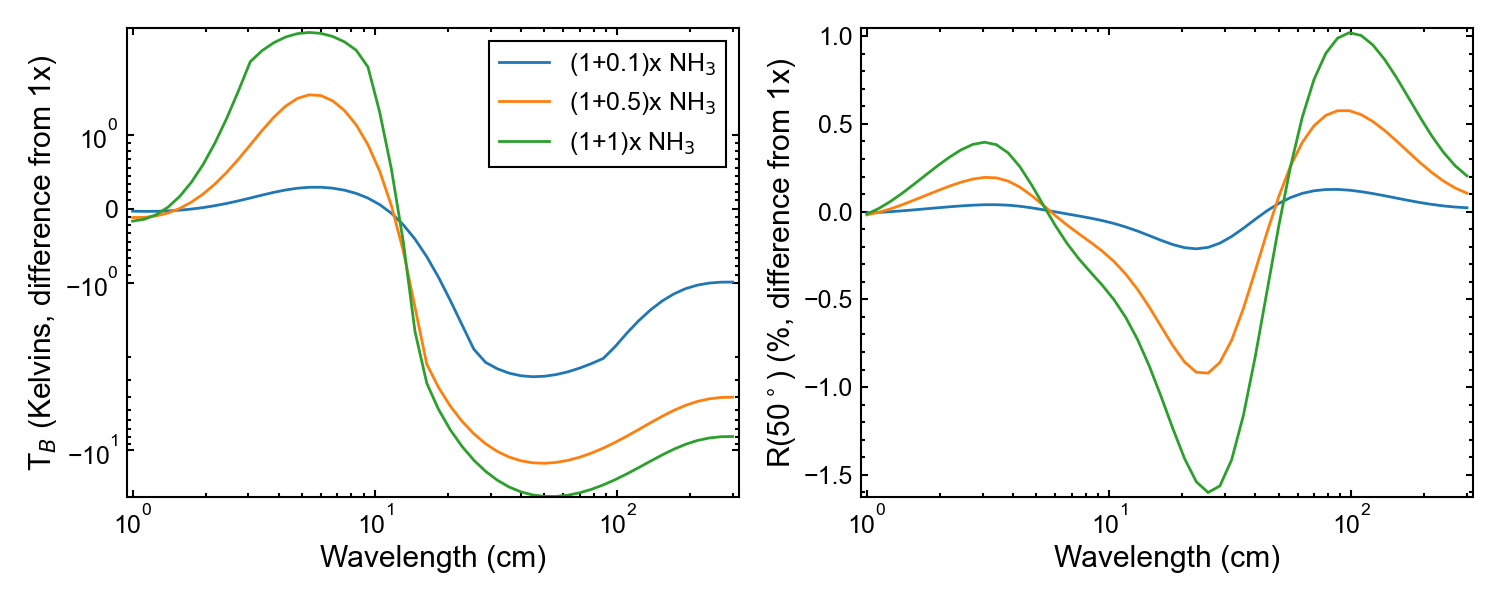

In [10]:
p_grid = np.logspace(2, 9, 10000)
uranus_gravity = 8.69  # m/s2 
planet_radius = 25559  
freq_ghz = 3e-1 / np.logspace(np.log10(1e-2), np.log10(3), 52)
wave_cm = spc.c / (freq_ghz * 1e9) * 1e2 

fig = plt.figure(figsize=(15, 6))
ax1 = fig.add_subplot(1,2,1)
ax2 = fig.add_subplot(1,2,2)

# Load RO profile 
uranus_ro = np.loadtxt('/Users/akins/Documents/Codes/ECCM_MRTM/data/ro_profiles/uranus_voyager2_lindal1987.txt', skiprows=3, delimiter=',')
uranus_pressure = uranus_ro[:, 0] * 1e2  # Pa
uranus_temperature = uranus_ro[:, 1]

# Baseline
gases1 = eccm.solar_to_deep_mole_fraction(50) 
gases2 = eccm.solar_to_deep_mole_fraction(35) 
gases3 = eccm.solar_to_deep_mole_fraction(1) 

pressure_grid, temperature_grid, altitude_grid, \
x_h2o, x_nh3, x_h2s, x_ch4, x_ph3, x_h2, x_he, \
a_h2osolid, a_h2oliquid, a_h2osolution, \
a_nh3solid, a_nh3liquid, \
a_h2ssolid, a_h2sliquid, \
a_nh4sh, c_nh3h2o, \
a_ch4solid, a_ch4liquid, a_ph3solid  = eccm.eccm(p_grid, uranus_pressure, uranus_temperature, uranus_gravity,
                                                 gases2['H2O'], gases3['NH3'], gases2['H2S'], gases1['CH4'], 0., 0.85, 0.15,
                                                 h2s_rh = 0.35, h2o_rh = 0.35,
                                                 latent_heat_update=True, force_reference_above_pressure=1.*spc.bar)

incang_deg = 0. 
# Don't need to use the full atmosphere grid
minloc = np.argmin(abs(pressure_grid / spc.bar - 1e-3))
maxloc = np.argmin(abs(pressure_grid / spc.bar - 1000e3))
slc = slice(maxloc, minloc, 3)
full_tau, weight_up, weight_limb, Tup, Tlimb = mrtm.mrtm(freq_ghz, incang_deg, altitude_grid[slc], pressure_grid[slc], temperature_grid[slc], x_h2o[slc], x_nh3[slc], x_h2s[slc], x_ch4[slc], x_ph3[slc], x_h2[slc], x_he[slc], planet_radius)
spec1 = Tup 
incang_deg = 50. 
full_tau, _, _, Tup, Tlimb = mrtm.mrtm(freq_ghz, incang_deg, altitude_grid[slc], pressure_grid[slc], temperature_grid[slc], x_h2o[slc], x_nh3[slc], x_h2s[slc], x_ch4[slc], x_ph3[slc], x_h2[slc], x_he[slc], planet_radius)
spec2 = Tup 
R50 = (spec1 - spec2) / spec1 * 1e2 
ref_spec = spec1
ref_50 = R50 

# Next 
gases1 = eccm.solar_to_deep_mole_fraction(50) 
gases2 = eccm.solar_to_deep_mole_fraction(35) 
gases3 = eccm.solar_to_deep_mole_fraction(1.1) 

pressure_grid, temperature_grid, altitude_grid, \
x_h2o, x_nh3, x_h2s, x_ch4, x_ph3, x_h2, x_he, \
a_h2osolid, a_h2oliquid, a_h2osolution, \
a_nh3solid, a_nh3liquid, \
a_h2ssolid, a_h2sliquid, \
a_nh4sh, c_nh3h2o, \
a_ch4solid, a_ch4liquid, a_ph3solid  = eccm.eccm(p_grid, uranus_pressure, uranus_temperature, uranus_gravity,
                                                 gases2['H2O'], gases3['NH3'], gases2['H2S'], gases1['CH4'], 0., 0.85, 0.15,
                                                 h2s_rh = 0.35, h2o_rh = 0.35,
                                                 latent_heat_update=True, force_reference_above_pressure=1.*spc.bar)

incang_deg = 0. 
full_tau, weight_up, weight_limb, Tup, Tlimb = mrtm.mrtm(freq_ghz, incang_deg, altitude_grid[slc], pressure_grid[slc], temperature_grid[slc], x_h2o[slc], x_nh3[slc], x_h2s[slc], x_ch4[slc], x_ph3[slc], x_h2[slc], x_he[slc], planet_radius)
spec1 = Tup 
incang_deg = 50. 
full_tau, _, _, Tup, Tlimb = mrtm.mrtm(freq_ghz, incang_deg, altitude_grid[slc], pressure_grid[slc], temperature_grid[slc], x_h2o[slc], x_nh3[slc], x_h2s[slc], x_ch4[slc], x_ph3[slc], x_h2[slc], x_he[slc], planet_radius)
spec2 = Tup 
R50 = (spec1 - spec2) / spec1 * 1e2 

ax1.plot(wave_cm, spec1-ref_spec, label='(1+0.1)x NH$_3$')
ax2.plot(wave_cm, R50-ref_50)

gases1 = eccm.solar_to_deep_mole_fraction(50) 
gases2 = eccm.solar_to_deep_mole_fraction(35) 
gases3 = eccm.solar_to_deep_mole_fraction(1.5) 

pressure_grid, temperature_grid, altitude_grid, \
x_h2o, x_nh3, x_h2s, x_ch4, x_ph3, x_h2, x_he, \
a_h2osolid, a_h2oliquid, a_h2osolution, \
a_nh3solid, a_nh3liquid, \
a_h2ssolid, a_h2sliquid, \
a_nh4sh, c_nh3h2o, \
a_ch4solid, a_ch4liquid, a_ph3solid  = eccm.eccm(p_grid, uranus_pressure, uranus_temperature, uranus_gravity,
                                                 gases2['H2O'], gases3['NH3'], gases2['H2S'], gases1['CH4'], 0., 0.85, 0.15,
                                                 h2s_rh = 0.35, h2o_rh = 0.35,
                                                 latent_heat_update=True, force_reference_above_pressure=1.*spc.bar)

incang_deg = 0. 
full_tau, weight_up, weight_limb, Tup, Tlimb = mrtm.mrtm(freq_ghz, incang_deg, altitude_grid[slc], pressure_grid[slc], temperature_grid[slc], x_h2o[slc], x_nh3[slc], x_h2s[slc], x_ch4[slc], x_ph3[slc], x_h2[slc], x_he[slc], planet_radius)
spec1 = Tup 
incang_deg = 50. 
full_tau, _, _, Tup, Tlimb = mrtm.mrtm(freq_ghz, incang_deg, altitude_grid[slc], pressure_grid[slc], temperature_grid[slc], x_h2o[slc], x_nh3[slc], x_h2s[slc], x_ch4[slc], x_ph3[slc], x_h2[slc], x_he[slc], planet_radius)
spec2 = Tup 
R50 = (spec1 - spec2) / spec1 * 1e2 

ax1.plot(wave_cm, spec1-ref_spec, label='(1+0.5)x NH$_3$')
ax2.plot(wave_cm, R50-ref_50)

gases1 = eccm.solar_to_deep_mole_fraction(50) 
gases2 = eccm.solar_to_deep_mole_fraction(35) 
gases3 = eccm.solar_to_deep_mole_fraction(2) 

pressure_grid, temperature_grid, altitude_grid, \
x_h2o, x_nh3, x_h2s, x_ch4, x_ph3, x_h2, x_he, \
a_h2osolid, a_h2oliquid, a_h2osolution, \
a_nh3solid, a_nh3liquid, \
a_h2ssolid, a_h2sliquid, \
a_nh4sh, c_nh3h2o, \
a_ch4solid, a_ch4liquid, a_ph3solid  = eccm.eccm(p_grid, uranus_pressure, uranus_temperature, uranus_gravity,
                                                 gases2['H2O'], gases3['NH3'], gases2['H2S'], gases1['CH4'], 0., 0.85, 0.15,
                                                 h2s_rh = 0.35, h2o_rh = 0.35,
                                                 latent_heat_update=True, force_reference_above_pressure=1.*spc.bar)

incang_deg = 0. 
full_tau, weight_up, weight_limb, Tup, Tlimb = mrtm.mrtm(freq_ghz, incang_deg, altitude_grid[slc], pressure_grid[slc], temperature_grid[slc], x_h2o[slc], x_nh3[slc], x_h2s[slc], x_ch4[slc], x_ph3[slc], x_h2[slc], x_he[slc], planet_radius)
spec1 = Tup 
incang_deg = 50. 
full_tau, _, _, Tup, Tlimb = mrtm.mrtm(freq_ghz, incang_deg, altitude_grid[slc], pressure_grid[slc], temperature_grid[slc], x_h2o[slc], x_nh3[slc], x_h2s[slc], x_ch4[slc], x_ph3[slc], x_h2[slc], x_he[slc], planet_radius)
spec2 = Tup 
R50 = (spec1 - spec2) / spec1 * 1e2 

ax1.plot(wave_cm, spec1-ref_spec, label='(1+1)x NH$_3$')
ax2.plot(wave_cm, R50-ref_50)

ax1.set_xlabel('Wavelength (cm)')
ax2.set_xlabel('Wavelength (cm)')
ax1.set_ylabel('T$_B$ (Kelvins, difference from 1x)')
ax2.set_ylabel('R(50$^\circ$) (%, difference from 1x)')
ax1.legend() 
ax1.set_xscale('log')
ax2.set_xscale('log')
ax1.set_yscale('symlog')
ax1.yaxis.set_minor_locator(MinorSymLogLocator(1e-1))
fig.tight_layout()
fig.savefig('uranus_ammonia')

### Deep H2S abundance

<>:131: SyntaxWarning: invalid escape sequence '\c'
<>:131: SyntaxWarning: invalid escape sequence '\c'
/var/folders/zg/yqp2bsw569ngkkjdlpj0b5cw0000gq/T/ipykernel_79948/2874158989.py:131: SyntaxWarning: invalid escape sequence '\c'
  ax2.set_ylabel('R(50$^\circ$) (%, difference from 3x)')


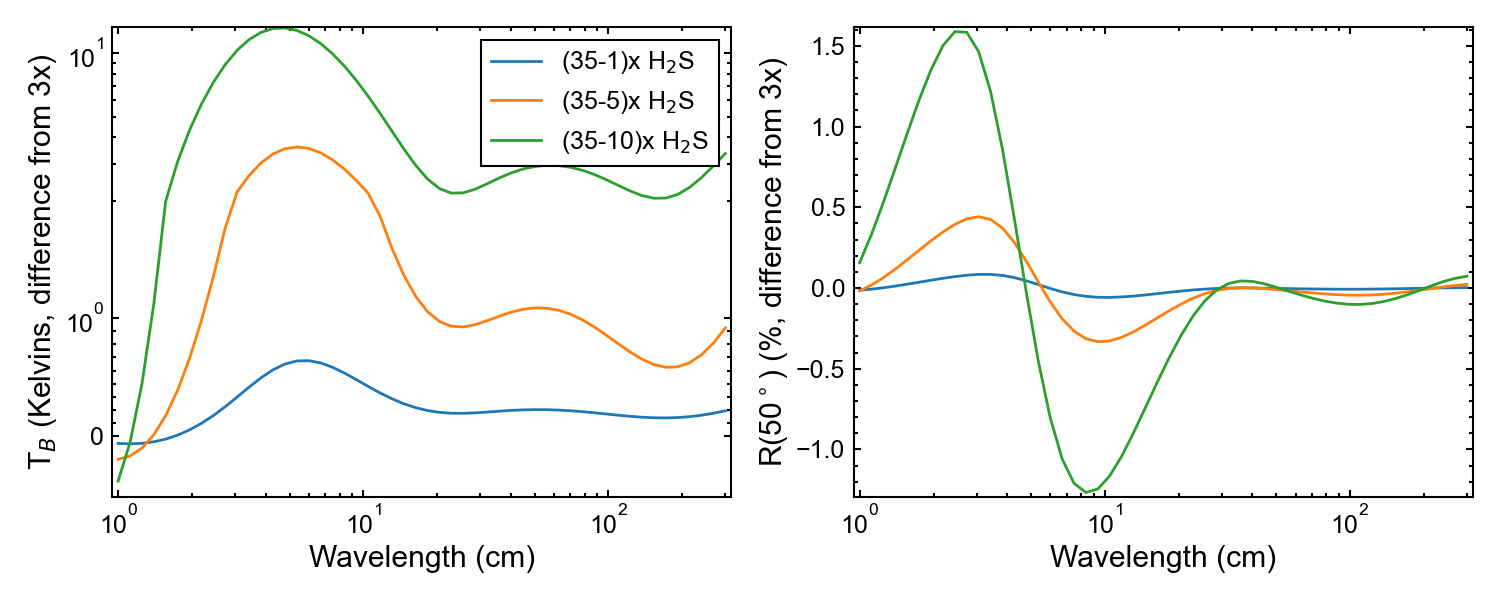

In [13]:
p_grid = np.logspace(2, 9, 10000)
uranus_gravity = 8.69  # m/s2 
planet_radius = 25559  
freq_ghz = 3e-1 / np.logspace(np.log10(1e-2), np.log10(3), 52)
wave_cm = spc.c / (freq_ghz * 1e9) * 1e2 

fig = plt.figure(figsize=(15, 6))
ax1 = fig.add_subplot(1,2,1)
ax2 = fig.add_subplot(1,2,2)

# Load RO profile 
uranus_ro = np.loadtxt('/Users/akins/Documents/Codes/ECCM_MRTM/data/ro_profiles/uranus_voyager2_lindal1987.txt', skiprows=3, delimiter=',')
uranus_pressure = uranus_ro[:, 0] * 1e2  # Pa
uranus_temperature = uranus_ro[:, 1]

# Baseline
gases1 = eccm.solar_to_deep_mole_fraction(50) 
gases2 = eccm.solar_to_deep_mole_fraction(35) 
gases3 = eccm.solar_to_deep_mole_fraction(1) 

pressure_grid, temperature_grid, altitude_grid, \
x_h2o, x_nh3, x_h2s, x_ch4, x_ph3, x_h2, x_he, \
a_h2osolid, a_h2oliquid, a_h2osolution, \
a_nh3solid, a_nh3liquid, \
a_h2ssolid, a_h2sliquid, \
a_nh4sh, c_nh3h2o, \
a_ch4solid, a_ch4liquid, a_ph3solid  = eccm.eccm(p_grid, uranus_pressure, uranus_temperature, uranus_gravity,
                                                 gases2['H2O'], gases3['NH3'], gases2['H2S'], gases1['CH4'], 0., 0.85, 0.15,
                                                 h2s_rh = 0.35, h2o_rh = 0.35,
                                                 latent_heat_update=True, force_reference_above_pressure=1.*spc.bar)

incang_deg = 0. 
# Don't need to use the full atmosphere grid
minloc = np.argmin(abs(pressure_grid / spc.bar - 1e-3))
maxloc = np.argmin(abs(pressure_grid / spc.bar - 1000e3))
slc = slice(maxloc, minloc, 3)
full_tau, weight_up, weight_limb, Tup, Tlimb = mrtm.mrtm(freq_ghz, incang_deg, altitude_grid[slc], pressure_grid[slc], temperature_grid[slc], x_h2o[slc], x_nh3[slc], x_h2s[slc], x_ch4[slc], x_ph3[slc], x_h2[slc], x_he[slc], planet_radius)
spec1 = Tup 
incang_deg = 50. 
full_tau, _, _, Tup, Tlimb = mrtm.mrtm(freq_ghz, incang_deg, altitude_grid[slc], pressure_grid[slc], temperature_grid[slc], x_h2o[slc], x_nh3[slc], x_h2s[slc], x_ch4[slc], x_ph3[slc], x_h2[slc], x_he[slc], planet_radius)
spec2 = Tup 
R50 = (spec1 - spec2) / spec1 * 1e2 
ref_spec = spec1
ref_50 = R50 

# Next 
gases1 = eccm.solar_to_deep_mole_fraction(50) 
gases2 = eccm.solar_to_deep_mole_fraction(35) 
gases3 = eccm.solar_to_deep_mole_fraction(1) 
gases4 = eccm.solar_to_deep_mole_fraction(34) 

pressure_grid, temperature_grid, altitude_grid, \
x_h2o, x_nh3, x_h2s, x_ch4, x_ph3, x_h2, x_he, \
a_h2osolid, a_h2oliquid, a_h2osolution, \
a_nh3solid, a_nh3liquid, \
a_h2ssolid, a_h2sliquid, \
a_nh4sh, c_nh3h2o, \
a_ch4solid, a_ch4liquid, a_ph3solid  = eccm.eccm(p_grid, uranus_pressure, uranus_temperature, uranus_gravity,
                                                 gases2['H2O'], gases3['NH3'], gases4['H2S'], gases1['CH4'], 0., 0.85, 0.15,
                                                 h2s_rh = 0.35, h2o_rh = 0.35,
                                                 latent_heat_update=True, force_reference_above_pressure=1.*spc.bar)

incang_deg = 0. 
full_tau, weight_up, weight_limb, Tup, Tlimb = mrtm.mrtm(freq_ghz, incang_deg, altitude_grid[slc], pressure_grid[slc], temperature_grid[slc], x_h2o[slc], x_nh3[slc], x_h2s[slc], x_ch4[slc], x_ph3[slc], x_h2[slc], x_he[slc], planet_radius)
spec1 = Tup 
incang_deg = 50. 
full_tau, _, _, Tup, Tlimb = mrtm.mrtm(freq_ghz, incang_deg, altitude_grid[slc], pressure_grid[slc], temperature_grid[slc], x_h2o[slc], x_nh3[slc], x_h2s[slc], x_ch4[slc], x_ph3[slc], x_h2[slc], x_he[slc], planet_radius)
spec2 = Tup 
R50 = (spec1 - spec2) / spec1 * 1e2 

ax1.plot(wave_cm, spec1-ref_spec, label='(35-1)x H$_2$S')
ax2.plot(wave_cm, R50-ref_50)

gases1 = eccm.solar_to_deep_mole_fraction(50) 
gases2 = eccm.solar_to_deep_mole_fraction(35) 
gases3 = eccm.solar_to_deep_mole_fraction(1) 
gases4 = eccm.solar_to_deep_mole_fraction(30.) 

pressure_grid, temperature_grid, altitude_grid, \
x_h2o, x_nh3, x_h2s, x_ch4, x_ph3, x_h2, x_he, \
a_h2osolid, a_h2oliquid, a_h2osolution, \
a_nh3solid, a_nh3liquid, \
a_h2ssolid, a_h2sliquid, \
a_nh4sh, c_nh3h2o, \
a_ch4solid, a_ch4liquid, a_ph3solid  = eccm.eccm(p_grid, uranus_pressure, uranus_temperature, uranus_gravity,
                                                 gases2['H2O'], gases3['NH3'], gases4['H2S'], gases1['CH4'], 0., 0.85, 0.15,
                                                 h2s_rh = 0.35, h2o_rh = 0.35,
                                                 latent_heat_update=True, force_reference_above_pressure=1.*spc.bar)

incang_deg = 0. 
full_tau, weight_up, weight_limb, Tup, Tlimb = mrtm.mrtm(freq_ghz, incang_deg, altitude_grid[slc], pressure_grid[slc], temperature_grid[slc], x_h2o[slc], x_nh3[slc], x_h2s[slc], x_ch4[slc], x_ph3[slc], x_h2[slc], x_he[slc], planet_radius)
spec1 = Tup 
incang_deg = 50. 
full_tau, _, _, Tup, Tlimb = mrtm.mrtm(freq_ghz, incang_deg, altitude_grid[slc], pressure_grid[slc], temperature_grid[slc], x_h2o[slc], x_nh3[slc], x_h2s[slc], x_ch4[slc], x_ph3[slc], x_h2[slc], x_he[slc], planet_radius)
spec2 = Tup 
R50 = (spec1 - spec2) / spec1 * 1e2 

ax1.plot(wave_cm, spec1-ref_spec, label='(35-5)x H$_2$S')
ax2.plot(wave_cm, R50-ref_50)

gases1 = eccm.solar_to_deep_mole_fraction(50) 
gases2 = eccm.solar_to_deep_mole_fraction(35) 
gases3 = eccm.solar_to_deep_mole_fraction(1) 
gases4 = eccm.solar_to_deep_mole_fraction(20) 

pressure_grid, temperature_grid, altitude_grid, \
x_h2o, x_nh3, x_h2s, x_ch4, x_ph3, x_h2, x_he, \
a_h2osolid, a_h2oliquid, a_h2osolution, \
a_nh3solid, a_nh3liquid, \
a_h2ssolid, a_h2sliquid, \
a_nh4sh, c_nh3h2o, \
a_ch4solid, a_ch4liquid, a_ph3solid  = eccm.eccm(p_grid, uranus_pressure, uranus_temperature, uranus_gravity,
                                                 gases2['H2O'], gases3['NH3'], gases4['H2S'], gases1['CH4'], 0., 0.85, 0.15,
                                                 h2s_rh = 0.35, h2o_rh = 0.35,
                                                 latent_heat_update=True, force_reference_above_pressure=1.*spc.bar)

incang_deg = 0. 
full_tau, weight_up, weight_limb, Tup, Tlimb = mrtm.mrtm(freq_ghz, incang_deg, altitude_grid[slc], pressure_grid[slc], temperature_grid[slc], x_h2o[slc], x_nh3[slc], x_h2s[slc], x_ch4[slc], x_ph3[slc], x_h2[slc], x_he[slc], planet_radius)
spec1 = Tup 
incang_deg = 50. 
full_tau, _, _, Tup, Tlimb = mrtm.mrtm(freq_ghz, incang_deg, altitude_grid[slc], pressure_grid[slc], temperature_grid[slc], x_h2o[slc], x_nh3[slc], x_h2s[slc], x_ch4[slc], x_ph3[slc], x_h2[slc], x_he[slc], planet_radius)
spec2 = Tup 
R50 = (spec1 - spec2) / spec1 * 1e2 

ax1.plot(wave_cm, spec1-ref_spec, label='(35-10)x H$_2$S')
ax2.plot(wave_cm, R50-ref_50)

ax1.set_xlabel('Wavelength (cm)')
ax2.set_xlabel('Wavelength (cm)')
ax1.set_ylabel('T$_B$ (Kelvins, difference from 3x)')
ax2.set_ylabel('R(50$^\circ$) (%, difference from 3x)')
ax1.legend() 
ax1.set_xscale('log')
ax2.set_xscale('log')
ax1.set_yscale('symlog')
ax1.yaxis.set_minor_locator(MinorSymLogLocator(1e-1))
fig.tight_layout()
fig.savefig('uranus_h2s')